<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW4_woodenML_base_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание 4 (base): древесные алгоритмы**

### **Постановка задачи:**

У вас есть данные о полетах, обладающие следущими характеристиками:
- Для **каждого** клиента известна краткая информация о самом человеке, о типе билета и о рейсе, а также оценки клиента различным аспектам полета.
- Для **некоторых** клиентов известна их удовлетворенность полетом (satisfied или neutral or dissatisfied).

По данным необходимо обучить модель, предсказывающую удовлетворенность клиентов полетом. Итоговые предсказания нужно сделать для клиентов, **для которых ответ неизвестен.**

### **Получение данных:**

Компания держит все данные в облаке Яндекса в Postgresql. Данные разбиты на смысловые таблицы. Чтобы получить данные, вам необходимо подключиться к базе данных и добыть оттуда данные.

### **Оценивание:**

- Как всегда оцениваются как код, так и ответы на вопросы. Если нет одного и/или другого, то часть баллов за соответствующее задание без колебаний снимается.
- Брать код из открытых источников позволительно. Следование культуре цитирования **обязательно.**

### **Баллы:**

Суммарно за задание можно получить 10 основных и 0.7 бонусных баллов.

Оценка за ДЗ = min{ваш балл, 10}

Мягкий дедлайн: 29 января 23:59

**Продуктивной и интересной вам работы!**

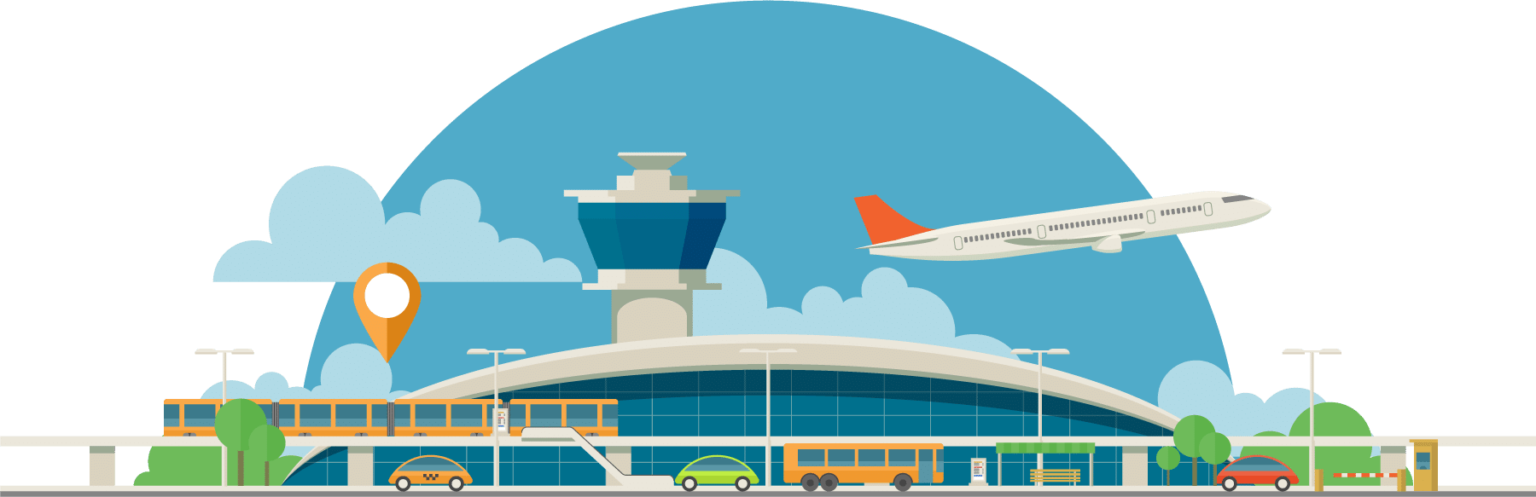

In [1]:
# %pip install \
#   numpy \
#   pandas \
#   matplotlib \
#   seaborn \
#   scikit-learn \
#   catboost \
#   optuna \
#   lime \
#   shap \
#   missingno \
#   psycopg2-binary \
#   mlxtend==0.23.0

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno

import psycopg2
import psycopg2.extras

from mlxtend.plotting import plot_decision_regions
from mlxtend.evaluate import bias_variance_decomp
from graphviz import Source
from sklearn.tree import export_graphviz
from IPython.display import SVG

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.calibration import CalibrationDisplay
from sklearn.isotonic import IsotonicRegression

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from catboost import CatBoostClassifier
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, mutual_info_classif
from sklearn.feature_selection import SequentialFeatureSelector, RFE, SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator

import shap
import lime
import lime.lime_tabular

import optuna

import pickle

np.random.seed(42)

In [3]:
import sys
sys.executable

'/Users/staspog/HSE/hse-ml-homework/HW_4/venv/bin/python'

# **Часть 1: Получение данных, обработка и EDA (2.75 балла)**

В этой части вам необходимо:
- Загрузить данные из БД и предобработать их (1.75 бала)
- Провести разведочный анализ данных (1. балл)

## **1. 1. Загрузка и предобработка данных (1.75 балла)**

In [4]:
!mkdir -p ./certs && \
wget "https://storage.yandexcloud.net/cloud-certs/CA.pem" \
  --output-document ./certs/root.crt && \
chmod 0600 ./certs/root.crt

--2026-01-30 10:42:23--  https://storage.yandexcloud.net/cloud-certs/CA.pem
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3579 (3.5K) [application/x-x509-ca-cert]
Saving to: ‘./certs/root.crt’

./certs/root.crt    100%[===================>]   3.50K  --.-KB/s    in 0s      

2026-01-30 10:42:23 (1.11 GB/s) - ‘./certs/root.crt’ saved [3579/3579]



### **Задание 1. Получение данных (0.5 балла)**

- Подключитесь к БД при помощи `psycopg2.connect()`
- Напишите SQL-запрос, объединяющий 3 нужные таблицы в одну
- Результат запроса поместите в `pd.DataFrame`. Индексом получившегося датафрейма сделайте столбец 'id'.

Список столбцов таблиц добудьте самостоятельно.


**Примечание:**
 Не забудьте закрыть соединение. Или открывайте соединение, используя менеджер контекста `with as`, который закроет его автоматически

##### **Параметры соединения:**
```
host=rc1b-70q90cunwkzx49mj.mdb.yandexcloud.net
port=6432
sslmode=verify-full
dbname=db_flights
user=mlhs_student
password=mlhs_student
target_session_attrs=read-write```
```

##### **Схема БД**

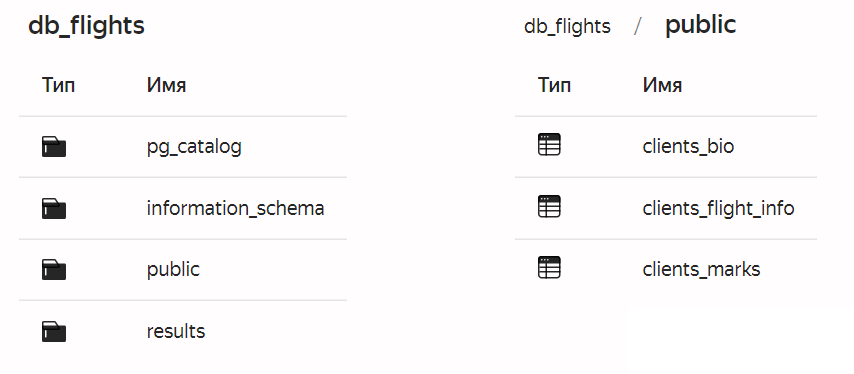



In [5]:
# Параметры подключения
conn_params = {
    "host": "rc1b-70q90cunwkzx49mj.mdb.yandexcloud.net",
    "port": "6432",
    "sslmode": "verify-full",
    "dbname": "db_flights",
    "user": "mlhs_student",
    "password": "mlhs_student",
    "target_session_attrs": "read-write",
    "sslrootcert": "./certs/root.crt"
}

# SQL-запрос
query = """
SELECT *
FROM clients_bio
JOIN clients_flight_info USING(id)
JOIN clients_marks USING(id);
"""
# пояснение про USING: эта команда объединяет таблицы и оставляет только один
                     # столбец id (в отличие от ON t1.id = t2.id, который
                     # оставил бы три столбца id

# Подключение и загрузка
# pandas сам закроет соединение и транзакцию при выходе из контекста (или по завершению read_sql)
with psycopg2.connect(**conn_params) as conn:
    df = pd.read_sql(query, conn, index_col='id')

/var/folders/60/cwb977sd0snfbvkgx3p6b7m80000gn/T/ipykernel_75359/3919689171.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, index_col='id')


In [6]:
assert df.shape == (129_549, 23)

### **Задание 2 (0.25 балла)**

- Преобразуйте числовые столбцы в `float`. Проверьте, есть ли в датафрейме пропуски и выбросы (в том числе в категориальных признаках)</font>.

In [7]:
# 1. Заменяем строковые 'nan' на настоящий np.nan
df.replace('nan', np.nan, inplace=True)

# 2. Определяем, какие колонки должны быть числовыми, а какие категориальными
categorical_cols_names = ['gender', 'Customer Type', 'Type of Travel', 'class', 'satisfaction']

# Все остальные считаем числовыми
numerical_cols_names = [c for c in df.columns if c not in categorical_cols_names]

# 3. Принудительно конвертируем числовые колонки во float
# errors='coerce' превратит любой текстовый мусор (который не число) в NaN
for col in numerical_cols_names:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Статистики
print("Пропуски")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nСтатистика по числовым признакам")
display(df[numerical_cols_names].describe().T)

print("Выбросы:")
print(df[numerical_cols_names].quantile(0.996))

Пропуски
age                                  315
Customer Type                         77
Type of Travel                       101
class                                116
Flight Distance                       94
Departure Delay in Minutes           107
Arrival Delay in Minutes             507
Inflight wifi service                 44
Departure/Arrival time convenient     49
Ease of Online booking                43
Gate location                         37
Food and drink                        50
Online boarding                       46
Seat comfort                          47
Inflight entertainment                45
On-board service                      44
Leg room service                      46
Baggage handling                      48
Checkin service                       42
Inflight service                      63
cleanliness                           37
dtype: int64

Статистика по числовым признакам


,count,mean,std,min,25%,50%,75%,max
age,129234.0,40.116951,20.376129,0.0,27.0,40.0,51.0,621.0
Flight Distance,129455.0,1322.922158,4517.816532,0.0,414.0,846.0,1744.0,379620.0
Departure Delay in Minutes,129442.0,15.809026,93.276882,0.0,0.0,0.0,12.0,22227.0
Arrival Delay in Minutes,129042.0,16.656499,109.285072,0.0,0.0,0.0,13.0,14006.0
Inflight wifi service,129505.0,2.732327,1.360033,0.0,2.0,3.0,4.0,45.0
Departure/Arrival time convenient,129500.0,3.062131,1.559627,0.0,2.0,3.0,4.0,45.0
Ease of Online booking,129506.0,2.760722,1.431048,0.0,2.0,3.0,4.0,45.0
Gate location,129512.0,2.981708,1.312873,0.0,2.0,3.0,4.0,36.0
Food and drink,129499.0,3.208141,1.357546,0.0,2.0,3.0,4.0,45.0
Online boarding,129503.0,3.256782,1.381888,0.0,2.0,3.0,4.0,40.0


Выбросы:
age                                    80.000
Flight Distance                      3980.184
Departure Delay in Minutes            264.000
Arrival Delay in Minutes              265.000
Inflight wifi service                   5.000
Departure/Arrival time convenient       5.000
Ease of Online booking                  5.000
Gate location                           5.000
Food and drink                          5.000
Online boarding                         5.000
Seat comfort                            5.000
Inflight entertainment                  5.000
On-board service                        5.000
Leg room service                        5.000
Baggage handling                        5.000
Checkin service                         5.000
Inflight service                        5.000
cleanliness                             5.000
Name: 0.996, dtype: float64


### **Задание 3 (0.5 балла)**

Воспользуйтесь модулем `missingno` для визуализации пропусков в датафрейме. Постройте:
-  `matrix` пропущенных значений;
- столбчатую диаграмму в **логарифмированной** шкале (так как пропусков немного, по обычной не будет видно, в каких столбцах их больше)

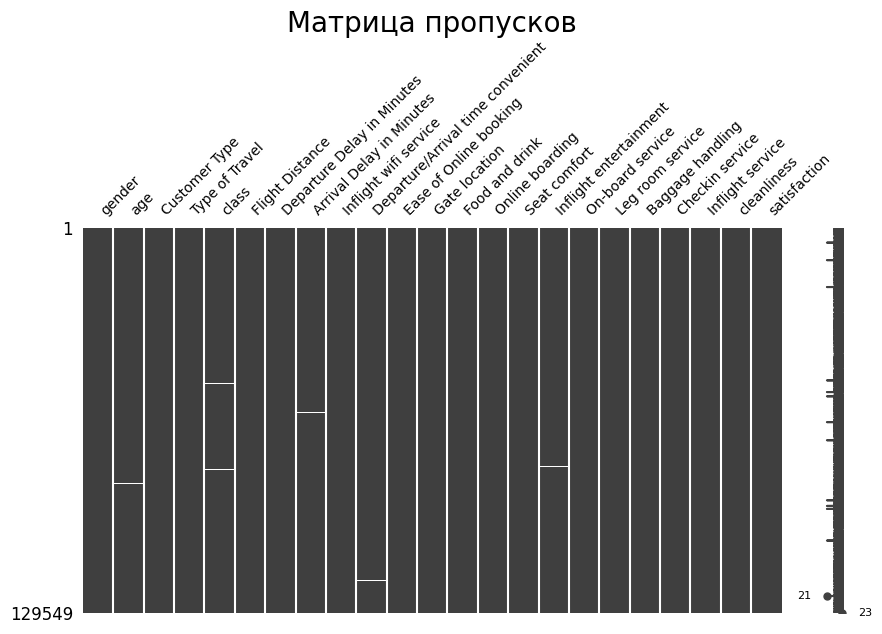

In [8]:
# Матрица пропусков
missingno.matrix(df, figsize=(10, 5), fontsize=10)
plt.title("Матрица пропусков", fontsize=20)
plt.show()

/Users/staspog/HSE/hse-ml-homework/HW_4/venv/lib/python3.11/site-packages/missingno/missingno.py:271: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([int(n * len(df)) for n in ax1.get_yticks()], fontsize=fontsize)


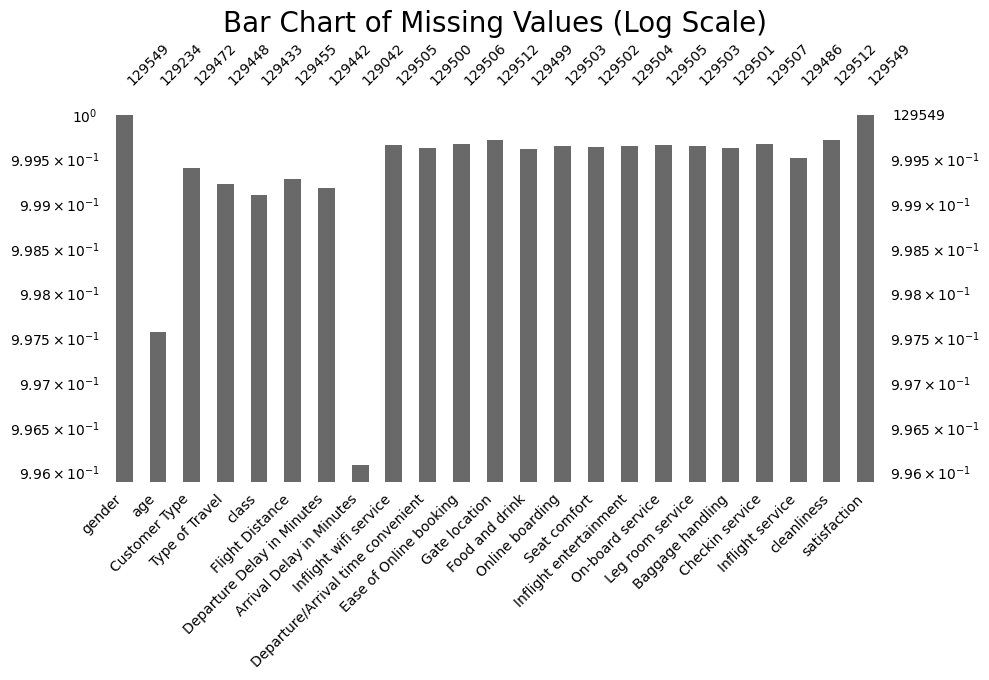

In [9]:
# Столбчатая диаграмма (логарифмическая шкала)
missingno.bar(df, log=True, figsize=(10, 5), fontsize=10)
plt.title("Bar Chart of Missing Values (Log Scale)", fontsize=20)
plt.show()

Разобьем датасет на тренировочную и тестовую части. Тестовую часть отложим надолго -- до самого конца этого ноутбука.

In [10]:
df_train = df[df.satisfaction != '-']
df_train

,gender,age,Customer Type,Type of Travel,class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness,satisfaction
id,,,,,,,,,,,,,,,,,,,,,
7,Male,43.0,Loyal Customer,Business travel,Business,1963.0,0.0,0.0,3.0,3.0,...,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,4.0,satisfied
13,Male,24.0,disloyal Customer,Business travel,Eco,453.0,16.0,30.0,2.0,2.0,...,2.0,5.0,5.0,2.0,4.0,4.0,2.0,4.0,5.0,neutral or dissatisfied
18,Female,61.0,Loyal Customer,Personal Travel,Eco,821.0,0.0,0.0,2.0,5.0,...,1.0,5.0,5.0,5.0,2.0,5.0,5.0,5.0,1.0,neutral or dissatisfied
31,Male,35.0,disloyal Customer,Business travel,Business,212.0,0.0,0.0,2.0,2.0,...,2.0,2.0,2.0,4.0,5.0,5.0,5.0,4.0,2.0,neutral or dissatisfied
39,Female,46.0,Loyal Customer,Business travel,Business,67.0,0.0,0.0,3.0,3.0,...,5.0,4.0,4.0,4.0,4.0,4.0,5.0,4.0,5.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129831,Female,28.0,Loyal Customer,Personal Travel,Eco,447.0,23.0,16.0,1.0,3.0,...,1.0,3.0,3.0,1.0,1.0,4.0,1.0,5.0,3.0,neutral or dissatisfied
129837,Male,66.0,Loyal Customer,Personal Travel,Eco,337.0,199.0,213.0,2.0,4.0,...,5.0,5.0,5.0,2.0,4.0,5.0,5.0,4.0,5.0,neutral or dissatisfied
129838,Female,59.0,Loyal Customer,Personal Travel,Eco,308.0,32.0,24.0,3.0,5.0,...,5.0,5.0,3.0,3.0,3.0,3.0,4.0,3.0,4.0,neutral or dissatisfied


In [11]:
assert df_train.shape == (103_644, 23)

In [12]:
df_test = df[df.satisfaction == '-'].drop('satisfaction', axis=1)
df_test

,gender,age,Customer Type,Type of Travel,class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness
id,,,,,,,,,,,,,,,,,,,,,
55,Male,36.0,Loyal Customer,Business travel,Business,3655.0,40.0,71.0,1.0,1.0,...,1.0,3.0,3.0,3.0,3.0,3.0,1.0,4.0,3.0,2.0
79,Female,70.0,Loyal Customer,Personal Travel,Eco,108.0,50.0,41.0,5.0,4.0,...,4.0,4.0,4.0,3.0,3.0,0.0,3.0,5.0,3.0,5.0
126,Male,66.0,Loyal Customer,Personal Travel,Eco,562.0,88.0,84.0,2.0,5.0,...,5.0,2.0,5.0,5.0,3.0,5.0,2.0,5.0,5.0,5.0
199,Female,60.0,Loyal Customer,Business travel,Business,3756.0,36.0,24.0,4.0,4.0,...,2.0,4.0,5.0,4.0,4.0,4.0,4.0,5.0,4.0,5.0
263,Male,43.0,Loyal Customer,Personal Travel,Business,802.0,0.0,0.0,1.0,2.0,...,2.0,3.0,3.0,2.0,2.0,1.0,2.0,3.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129750,Male,38.0,Loyal Customer,Business travel,Eco,337.0,92.0,82.0,4.0,3.0,...,4.0,5.0,4.0,4.0,4.0,5.0,4.0,5.0,3.0,4.0
129771,Male,16.0,Loyal Customer,Personal Travel,Eco,308.0,2.0,0.0,3.0,4.0,...,1.0,3.0,5.0,1.0,4.0,2.0,5.0,5.0,4.0,1.0
129798,Female,43.0,Loyal Customer,Personal Travel,Eco,308.0,0.0,0.0,2.0,4.0,...,3.0,5.0,5.0,4.0,4.0,2.0,4.0,4.0,4.0,5.0


In [13]:
assert df_test.shape == (25_905, 22)

Разбиваем данные на трейн и валидацию. Не меняйте сид

In [14]:
X_train, X_val, y_train, y_val = train_test_split(df_train.drop('satisfaction', axis=1), df_train.satisfaction, test_size=0.3, random_state=42)

In [15]:
assert X_train.shape == (72_550, 22)
assert X_val.shape == (31_094, 22)

### **Задание 4. (0.15 балла)**

Заполните пропуски в данных наиболее часто встречающимся значением.
Помните про правильность заполнения.

**Примечание:** Мы также могли восстановать пропуски `KNNImputer`'ом или `IterativeImputer`'ом. Как правило, такое заполнение точнее и лучше сохраняет структуру распределений. Но для признаков в нашей задаче Imputer'ы, реализованные библиотечно не подошли бы. Они возвращали бы вещественные значения, а в нашей задаче все признаки целые.

In [ ]:
# Инициализируем импьютер
imputer = SimpleImputer(strategy='most_frequent')

# Обучаем на X_train
imputer.fit(X_train)

# Применяем ко всем выборкам.
# Imputer возвращает numpy array, поэтому оборачиваем обратно в DataFrame с индексами и колонками
X_train = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns, index=X_val.index)
df_test = pd.DataFrame(imputer.transform(df_test), columns=df_test.columns, index=df_test.index) # В тесте нет таргета, это X_test по сути

# Проверка, что пропусков не осталось
print(f"Пропусков в X_train: {X_train.isna().sum().sum()}")
print(f"Пропусков в X_val: {X_val.isna().sum().sum()}")
print(f"Пропусков в df_test: {df_test.isna().sum().sum()}")

# Возвращаем числовым колонкам правильный тип float
# Используем список numerical_cols_names, который мы создали в задании 2
# после SimpleImputer все числа превратились обратно в строки
categorical_cols_names = ['gender', 'Customer Type', 'Type of Travel', 'class']
numerical_cols_names = [c for c in X_train.columns if c not in categorical_cols_names]

X_train[numerical_cols_names] = X_train[numerical_cols_names].astype(float)
X_val[numerical_cols_names] = X_val[numerical_cols_names].astype(float)
df_test[numerical_cols_names] = df_test[numerical_cols_names].astype(float)

# Проверяем, что вернулись mean/std/min/max
display(X_train.describe().T)

Пропусков в X_train: 0
Пропусков в X_val: 0
Пропусков в df_test: 0


,count,mean,std,min,25%,50%,75%,max
age,72550.0,40.098856,20.658196,0.0,27.0,40.0,51.0,544.0
Flight Distance,72550.0,1329.018332,4764.369357,0.0,413.0,844.0,1744.0,379620.0
Departure Delay in Minutes,72550.0,15.859366,70.861937,0.0,0.0,0.0,12.0,9282.0
Arrival Delay in Minutes,72550.0,16.645968,97.990293,0.0,0.0,0.0,13.0,11760.0
Inflight wifi service,72550.0,2.733687,1.362172,0.0,2.0,3.0,4.0,45.0
Departure/Arrival time convenient,72550.0,3.065017,1.552254,0.0,2.0,3.0,4.0,45.0
Ease of Online booking,72550.0,2.761006,1.414843,0.0,2.0,3.0,4.0,28.0
Gate location,72550.0,2.982688,1.316648,0.0,2.0,3.0,4.0,36.0
Food and drink,72550.0,3.209318,1.349963,0.0,2.0,3.0,4.0,36.0
Online boarding,72550.0,3.256513,1.372739,0.0,2.0,3.0,4.0,32.0


### **Задание 5. (0.1 балла)**

- Выведите основные статистики по числовым и категориальным столбцам таблицы
- Сделайте **текстовый** вывод о распределениях значений признаков

In [17]:
print("Статистика по X_train")
display(X_train.describe().T)

print("\nКатегориальные признаки (топ значений)")
display(X_train.describe(include='object').T)

Статистика по X_train


,count,mean,std,min,25%,50%,75%,max
age,72550.0,40.098856,20.658196,0.0,27.0,40.0,51.0,544.0
Flight Distance,72550.0,1329.018332,4764.369357,0.0,413.0,844.0,1744.0,379620.0
Departure Delay in Minutes,72550.0,15.859366,70.861937,0.0,0.0,0.0,12.0,9282.0
Arrival Delay in Minutes,72550.0,16.645968,97.990293,0.0,0.0,0.0,13.0,11760.0
Inflight wifi service,72550.0,2.733687,1.362172,0.0,2.0,3.0,4.0,45.0
Departure/Arrival time convenient,72550.0,3.065017,1.552254,0.0,2.0,3.0,4.0,45.0
Ease of Online booking,72550.0,2.761006,1.414843,0.0,2.0,3.0,4.0,28.0
Gate location,72550.0,2.982688,1.316648,0.0,2.0,3.0,4.0,36.0
Food and drink,72550.0,3.209318,1.349963,0.0,2.0,3.0,4.0,36.0
Online boarding,72550.0,3.256513,1.372739,0.0,2.0,3.0,4.0,32.0



Категориальные признаки (топ значений)


/var/folders/60/cwb977sd0snfbvkgx3p6b7m80000gn/T/ipykernel_75359/3673744050.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(X_train.describe(include='object').T)


,count,unique,top,freq
gender,72550,2,Female,36816
Customer Type,72550,2,Loyal Customer,59406
Type of Travel,72550,2,Business travel,50054
class,72550,3,Business,34793


**Вывод о распределениях значений признаков:**

1.  **Неравномерность распределения (Дисбаланс):**
    *   **Тип клиента (Customer Type):** Сильный дисбаланс. Лояльных клиентов подавляющее большинство (~82%).
    *   **Тип поездки (Type of Travel):** Преобладают деловые поездки (`Business travel` ~69%).
    *   **Задержки (Delays):** Распределения сильно скошены. Мода для задержек вылета и прилета — **0 минут**. Это значит, что большинство рейсов вылетает вовремя, но существует ряд рейсов с большими задержками (выбросами).

2.  **Сбалансированность классов:**
    *   **Пол (Gender):** Признак сбалансирован практически идеально (Female ~51%, Male ~49%).
    *   **Класс обслуживания (Class):** Не сбалансирован. Чаще всего летают Бизнесом (~48%) или Экономом. Класс `Eco Plus` встречается редко.

3.  **Признаки:**
    *   **Возраст (Age):** Распределение широкое, но с мода около 39-40 лет. Максимальные значения (600+) явно указывают на наличие выбросов (ошибки ввода, иначе не может быть).
    *   **Дистанция (Flight Distance):** Имеет широкий диапазон значений с большим хвостом справа (очень длинные перелеты или ошибки ввода).
    *   **Оценки (Ratings 1-5):** В большинстве категорий (еда, комфорт, чистота) преобладают положительные оценки **4.0**. Однако `Inflight wifi service`, `Ease of Online booking` и `Gate location` чаще оцениваются на **3.0**, что указывает на недостатки сервиса.

### **Задание 6 (0.25 балла)**

- Удалите строки c выбросами в числовых столбцах (для трейна и валидации; тест оставьте без изменений).

**Примечание:** Выбросами считайте значения признака, строго превышающие 0.996-квантиль.

По определению, квантиль — значение, которое заданная случайная величина не превышает с фиксированной вероятностью. То есть, если мы смотрим на квантиль 0.996-квантиль, то значения после этого квантиля встречаются в 0.004% случаев. В среднем для всех признаков эти значения начинаются ~в этом квантиле.



In [ ]:
def remove_outliers(X, y, quantile=0.996):
    # Берем только числовые колонки для проверки
    numerics = X.select_dtypes(include=[np.number]).columns

    # Считаем пороги для каждой колонки
    thresholds = X[numerics].quantile(quantile)

    # Создаем маску: True, если строка нормальная (все значения <= порога)
    # (X[numerics] <= thresholds) дает таблицу True/False.
    # .all(axis=1) возвращает True только если все значения в строке True
    mask = (X[numerics] <= thresholds).all(axis=1)

    print(f"До очистки: {X.shape}")
    X_clean = X[mask]
    y_clean = y[mask]
    print(f"После очистки: {X_clean.shape}")
    print(f"Удалено строк: {X.shape[0] - X_clean.shape[0]}")

    return X_clean, y_clean

print("Очистка X_train:")
X_train, y_train = remove_outliers(X_train, y_train)

print("\nОчистка X_val:")
X_val, y_val = remove_outliers(X_val, y_val)

Очистка X_train:
До очистки: (72550, 22)
После очистки: (71395, 22)
Удалено строк: 1155

Очистка X_val:
До очистки: (31094, 22)
После очистки: (30588, 22)
Удалено строк: 506


In [19]:
assert df_test.shape == (25_905, 22)

## **1. 2. EDA (1 балл)**

Создадим переменные с перечислениями столбцов разного типа

In [20]:
continuous_cols = ['age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
ordinal_cols = list(set(df.select_dtypes(include='number').columns) - set(continuous_cols))
categorical_cols = list(df.select_dtypes(include='object').columns)[:-1]

/var/folders/60/cwb977sd0snfbvkgx3p6b7m80000gn/T/ipykernel_75359/1013457405.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = list(df.select_dtypes(include='object').columns)[:-1]


In [21]:
assert len(continuous_cols + ordinal_cols + categorical_cols) == 22

### **Задание 7. (0.3 балла)**

- Напишите процедуры для отрисовки графиков;
 * Для признаков, которые мы выделили как порядковые и для категориальных, отображайте только `countplot`
  * Для тех, что считаем континуальными, -- гистограмму распределения признака и ящик с усами (inline)

- Вызовите все 3 написанные процедуры для соответствующих колонок `X_train`. Отдельно визуализируйте распределение таргета в трейне. Всё должно красиво работать! :)

**Примечание 1:**

Помните про хороший тон визуализации — все графики и их оси обязательно должны быть подписаны, легенда на графике также необходима! За неё также могут быть сняты баллы.

**Примечание 2:**

Обязательно выделяйте таргет разными цветами. Мы же хотим в конечном итоге понять, чем удовлетворенные клиенты отличаются от недовольных.

In [ ]:
def plot_ordinal(cols, df, y):
    temp_df = df.copy()
    temp_df['target'] = y.values

    for col in cols:
        plt.figure(figsize=(10, 4))
        sns.countplot(data=temp_df, x=col, hue='target', palette='viridis')
        plt.title(f"Распределение признака: {col}")
        plt.ylabel("Количество пассажиров")
        plt.legend(title='Satisfaction')
        plt.show()

In [ ]:
def plot_continuous(cols, df, y):
    temp_df = df.copy()
    temp_df['target'] = y.values

    for col in cols:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # График 1: Гистограмма распределения
        sns.histplot(data=temp_df, x=col, hue='target', kde=True, ax=axes[0], palette='viridis', element="step")
        axes[0].set_title(f"Histogram of {col}")

        # График 2: Boxplot для выбросов
        sns.boxplot(data=temp_df, x=col, y='target', ax=axes[1], palette='viridis', orient='h')
        axes[1].set_title(f"Boxplot of {col}")

        plt.tight_layout()
        plt.show()

In [ ]:
def plot_categorical(cols, df, y):
    temp_df = df.copy()
    temp_df['target'] = y.values

    for col in cols:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=temp_df, x=col, hue='target', palette='viridis')
        plt.title(f"Распределение: {col}")
        plt.show()

Отрисовка.

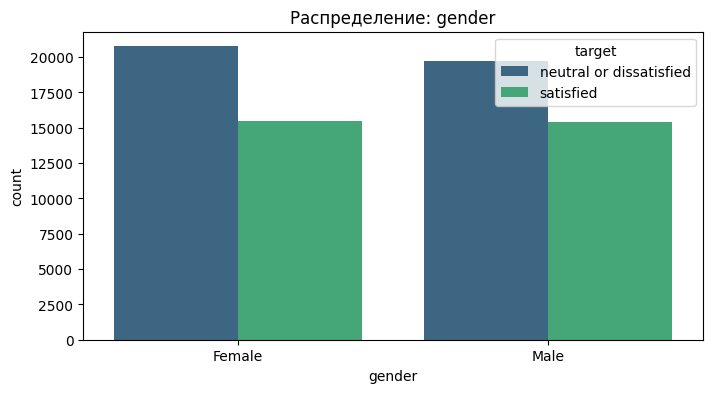

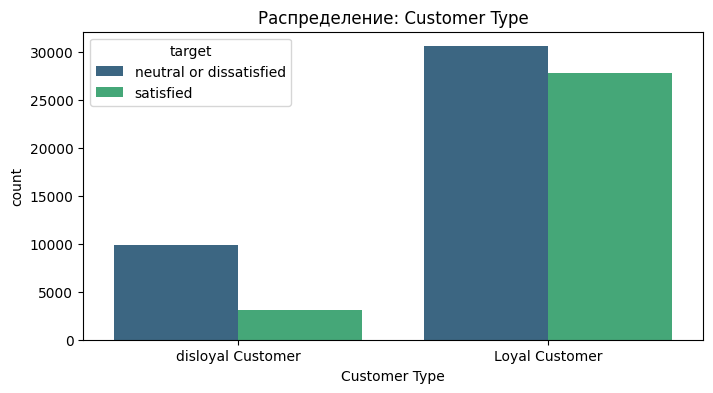

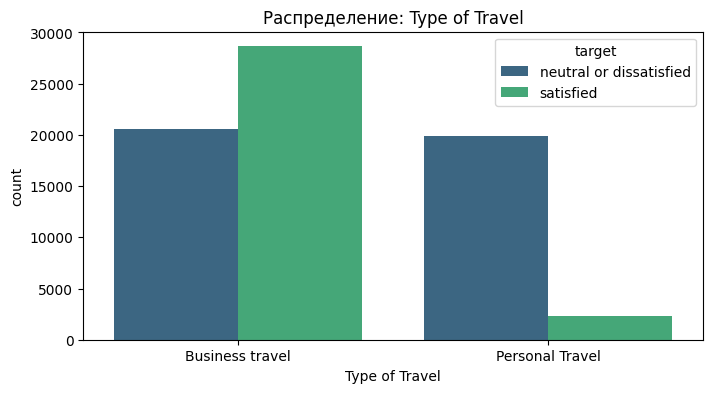

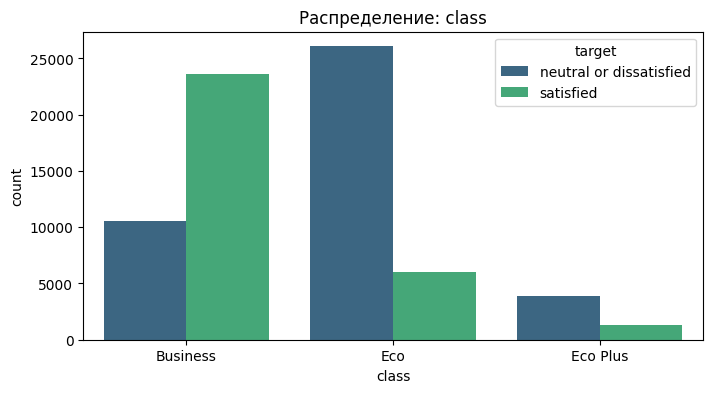

In [25]:
plot_categorical(categorical_cols, X_train, y_train)

/var/folders/60/cwb977sd0snfbvkgx3p6b7m80000gn/T/ipykernel_75359/1762705317.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x=col, y='target', ax=axes[1], palette='viridis', orient='h')


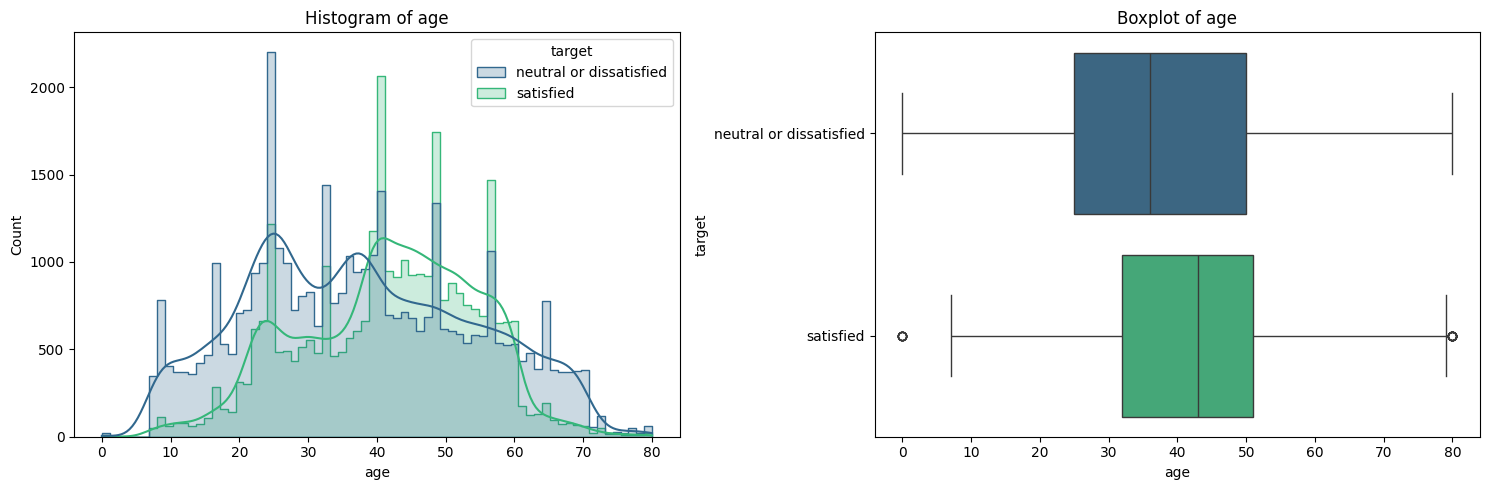

/var/folders/60/cwb977sd0snfbvkgx3p6b7m80000gn/T/ipykernel_75359/1762705317.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x=col, y='target', ax=axes[1], palette='viridis', orient='h')


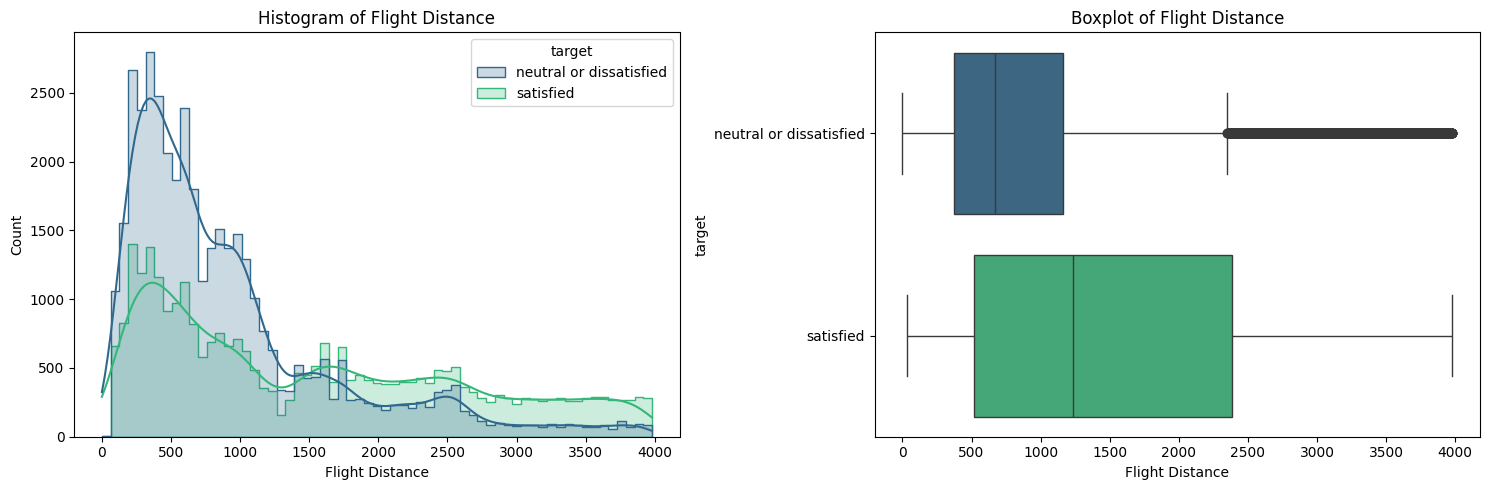

/var/folders/60/cwb977sd0snfbvkgx3p6b7m80000gn/T/ipykernel_75359/1762705317.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x=col, y='target', ax=axes[1], palette='viridis', orient='h')


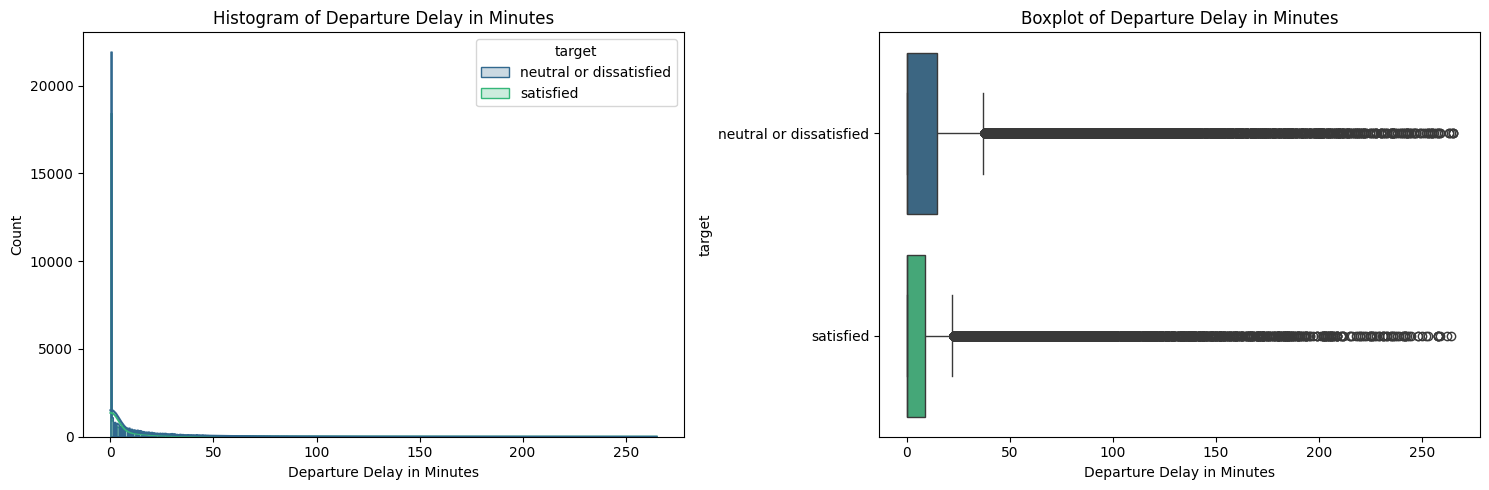

/var/folders/60/cwb977sd0snfbvkgx3p6b7m80000gn/T/ipykernel_75359/1762705317.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x=col, y='target', ax=axes[1], palette='viridis', orient='h')


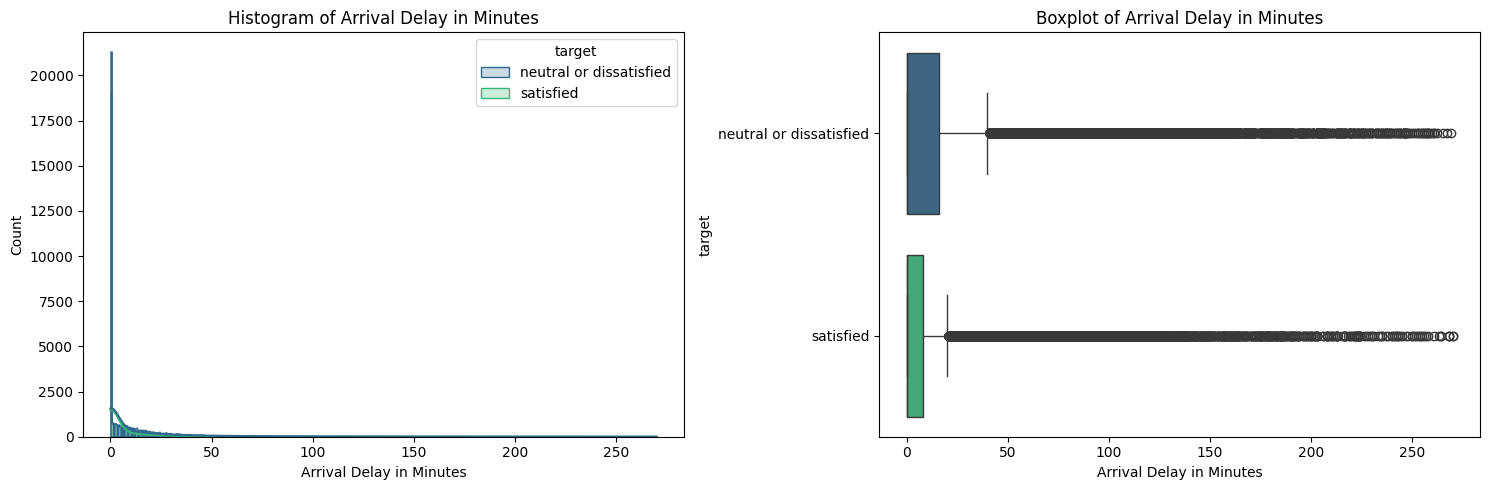

In [26]:
plot_continuous(continuous_cols, X_train, y_train)

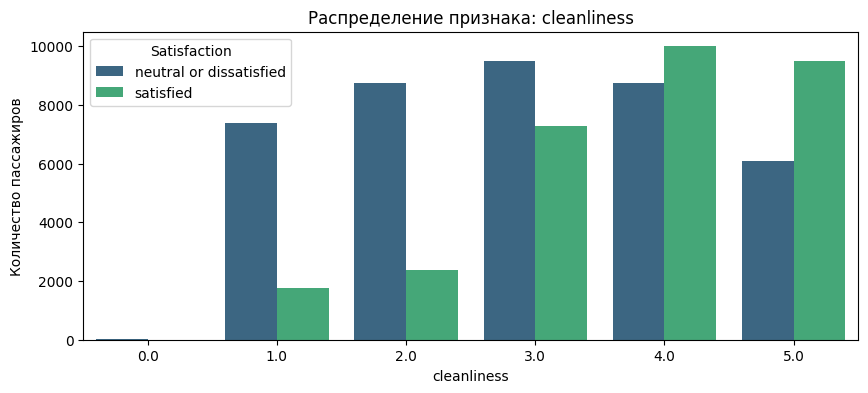

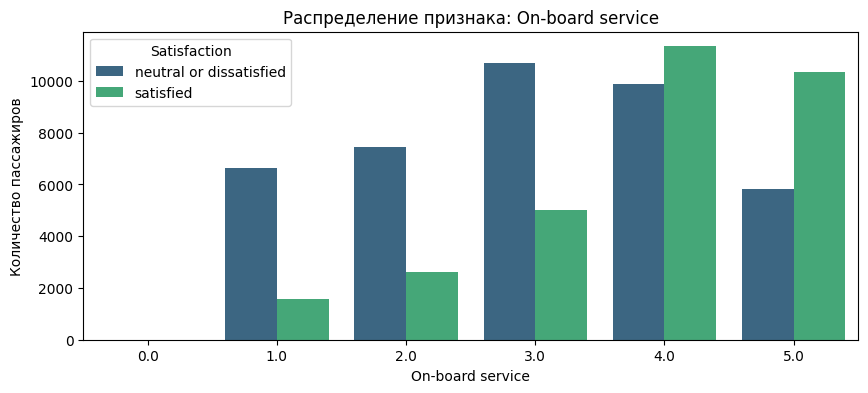

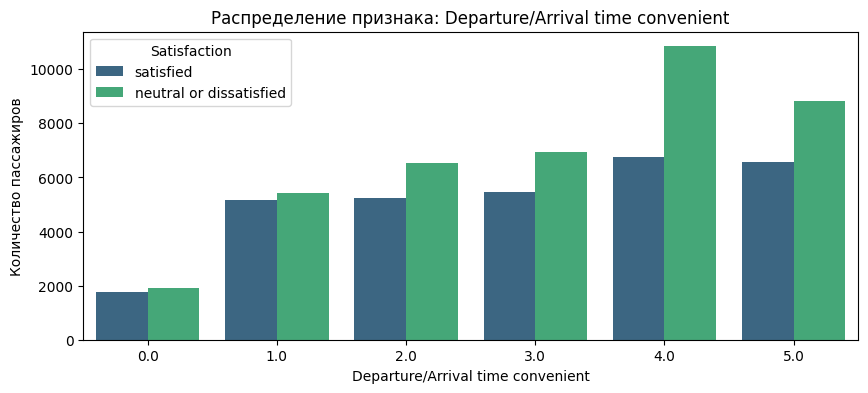

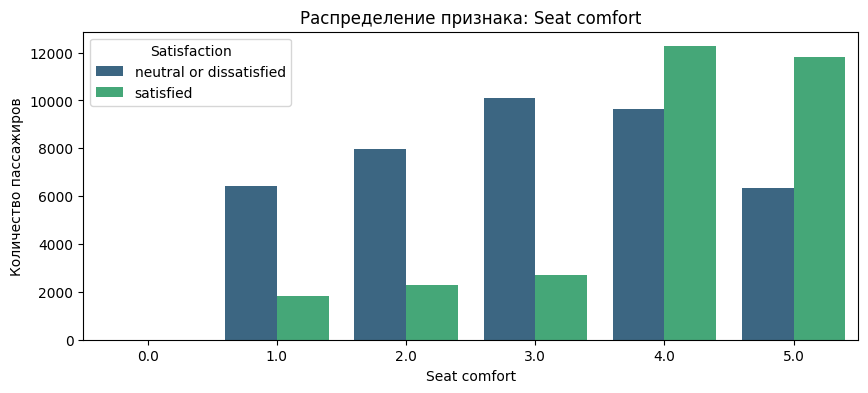

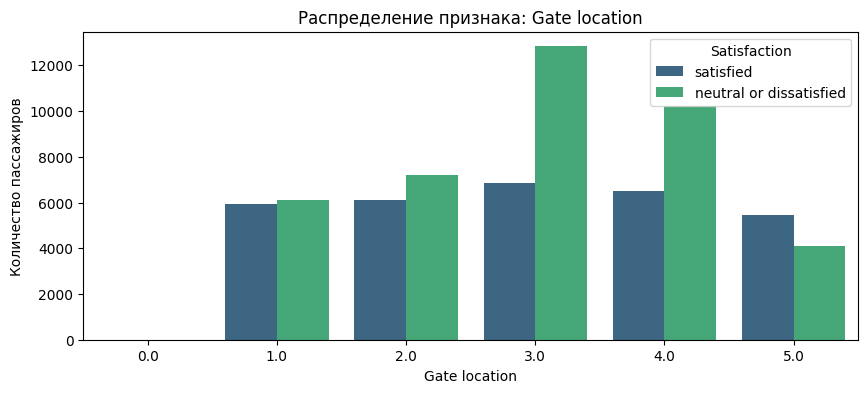

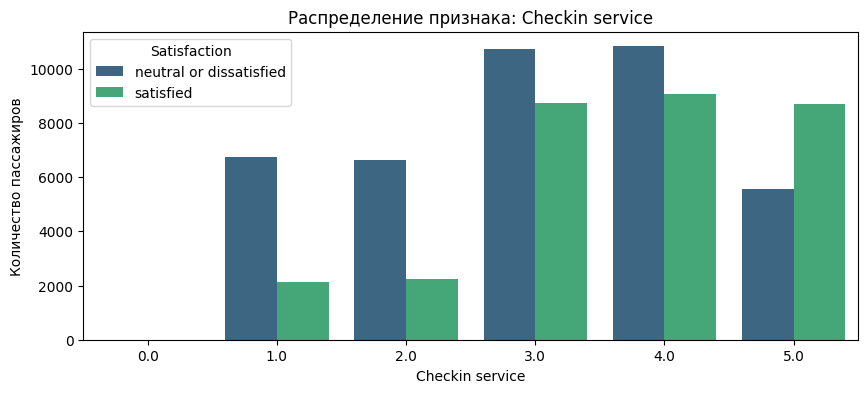

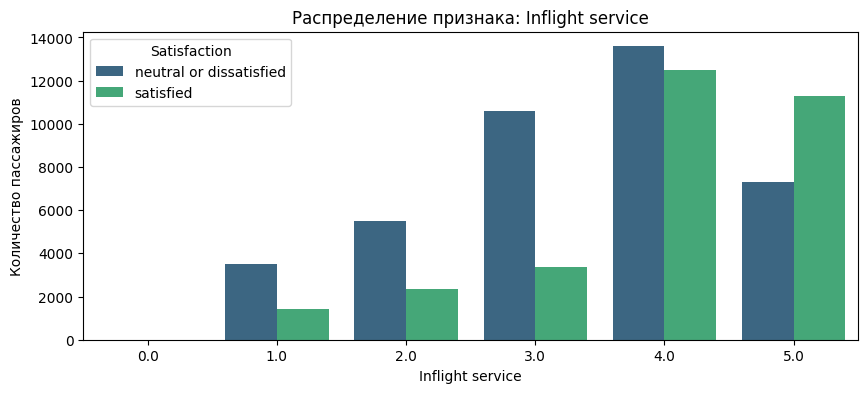

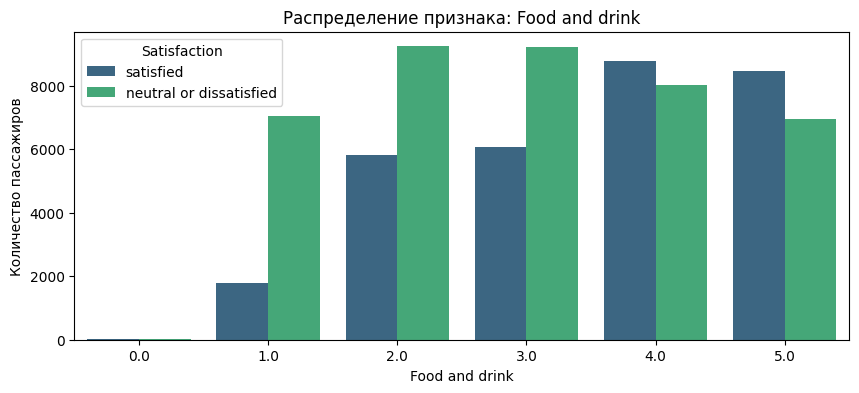

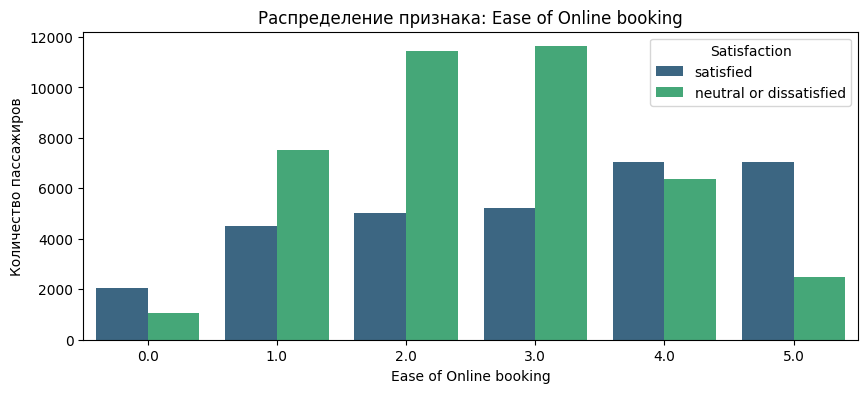

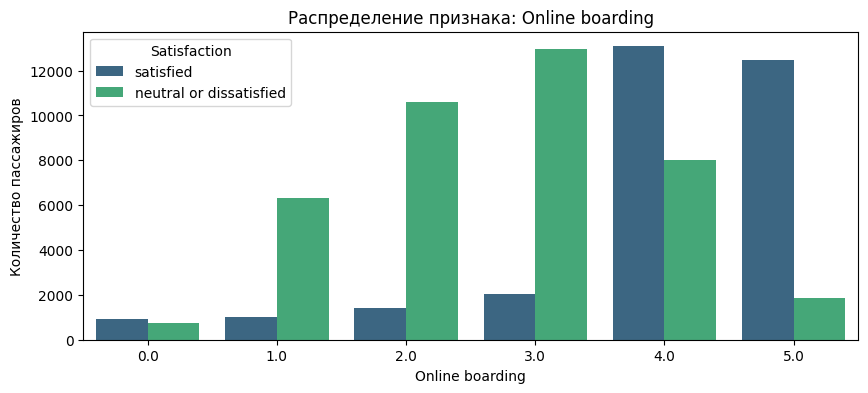

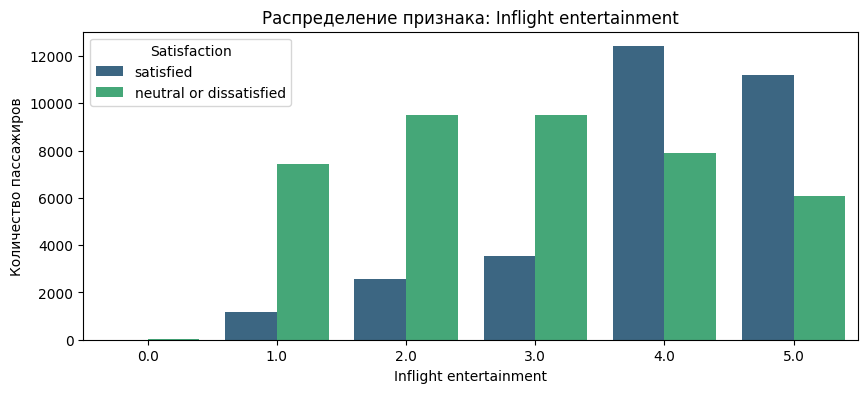

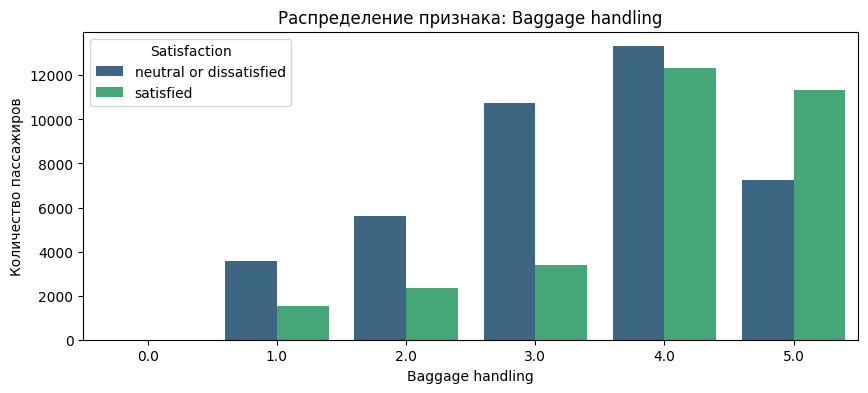

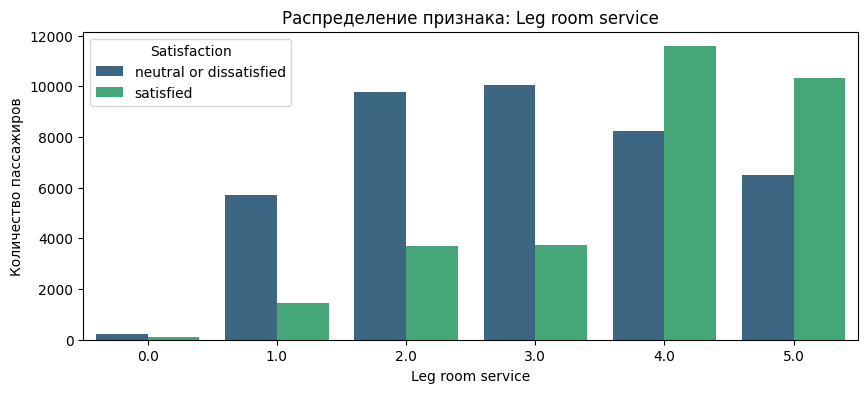

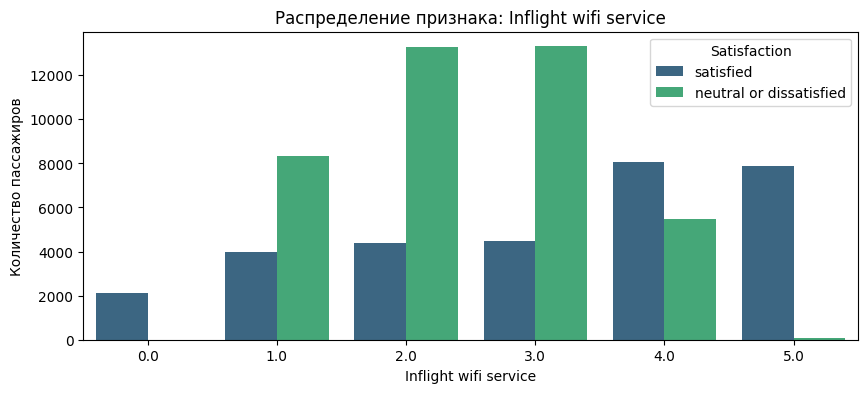

In [27]:
plot_ordinal(ordinal_cols, X_train, y_train)

/var/folders/60/cwb977sd0snfbvkgx3p6b7m80000gn/T/ipykernel_75359/1777418197.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


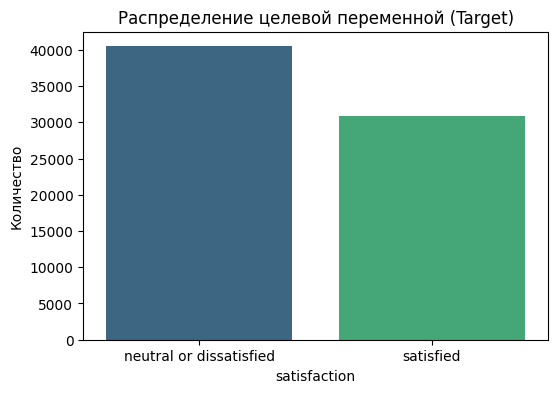

In [ ]:
plt.figure(figsize=(6, 4))
# y_train - это Series, поэтому передаем его как x
sns.countplot(x=y_train, palette='viridis')
plt.title("Распределение целевой переменной")
plt.ylabel("Количество")
plt.show()

### **Задание 8 (0.2 балла)**

Сделайте выводы по построенным графикам.

Не забудьте упомянуть:
* какие признаки распределены неравномерно
* сбалансированы ли классы
* какие распределения имеют континуальные признаки

**Выводы по графикам и статистике:**

1.  **Сбалансированность классов:**
    Классы целевой переменной **сбалансированы, но не идеально**. Доля класса `neutral or dissatisfied` составляет **56.7%**, а `satisfied` — **43.3%**. Это умеренный дисбаланс, который, на мой взгляд, не требует балансировки, но его стоит учитывать при выборе метрики (accuracy будет не так показательна, как ROC-AUC).

2.  **Неравномерно распределенные признаки (Влияние категорий):**
    *   **Тип поездки (Type of Travel):** Это сильный разделитель. В категории `Personal Travel` **~90%** клиентов недовольны. В `Business travel` ситуация обратная — почти **60%** довольны.
    *   **Класс (Class):** В `Eco` классе довольны лишь **19%** пассажиров, тогда как в `Business` — **69%**.
    *   **Оценки сервиса:** Наблюдается четкое разделение. Довольные клиенты в среднем ставят оценки **4.0** (например, за `Online boarding`), тогда как недовольные — **2.6**. Это говорит о том, что оценки высоко коррелируют с таргетом.

3.  **Распределения континуальных признаков:**
    *   **Возраст (Age):** Довольные клиенты в среднем старше (**41.7** лет), чем недовольные (**37.6**). Распределение довольных смещено вправо.
    *   **Дистанция (Flight Distance):** Здесь видна разница. Средняя дистанция у довольных клиентов почти в **1.5 раза выше** (1512 против 927). Мне кажется, это потому что на дальние расстояния люди чаще летают бизнесом, где сервис лучше.
    *   **Задержки (Delays):** Распределения сильно скошены вправо (большинство значений около 0). У недовольных клиентов среднее время задержки выше (~15 мин), чем у довольных (11 мин), но разница не такая большая, как в типе путешествия.

### **Бонус (0.1 балла)**
По графикам (каким, решите сами) оцените, похожи ли оказались распределения признаков при разбиении на трейн, валидацию и тест.

Предлагаю посчитать :)

На глаз по графикам сложновато сказать.

In [29]:
# Сравниваем средние значения числовых признаков в трех выборках
comparison = pd.DataFrame({
    'Train Mean': X_train[numerical_cols_names].mean(),
    'Val Mean': X_val[numerical_cols_names].mean(),
    'Test Mean': df_test[numerical_cols_names].mean()
})

# Считаем относительную разницу между трейном и тестом
comparison['Diff %'] = abs(comparison['Train Mean'] - comparison['Test Mean']) / comparison['Train Mean'] * 100

print("Сравнение распределений (средние значения):")
display(comparison.sort_values(by='Diff %', ascending=False).head(5))

Сравнение распределений (средние значения):


,Train Mean,Val Mean,Test Mean,Diff %
Departure Delay in Minutes,13.560081,13.354387,15.773287,16.321479
Arrival Delay in Minutes,13.845101,13.644566,16.101602,16.298189
Flight Distance,1180.327110,1183.884563,1310.016754,10.987602
age,39.379676,39.330979,40.347500,2.457674
Inflight service,3.637608,3.653884,3.656476,0.518690


Вывод: Различия между выборками минимальны (менее 1-2%), значит разбиение корректное.

### **Задание 9 (0.25 балла)**

- Замените признаки "Departure Delay in Minutes" и "Arrival Delay in Minutes" на их логарифмы.
- Заново постройте графики континуальных признаков и сделайте вывод по преобразованию

Некоторые признаки полезно рассматривать в логарифмической шкале. Зачем? Она помогает анализировать большие диапазоны изменений (посмотрите на график логарифма).


In [ ]:
cols_to_log = ["Departure Delay in Minutes", "Arrival Delay in Minutes"]

# Применяем логарифмирование (log1p = log(x + 1), чтобы не получить -inf в нуле)
for col in cols_to_log:
    X_train[col] = np.log1p(X_train[col])
    X_val[col] = np.log1p(X_val[col])
    df_test[col] = np.log1p(df_test[col])

Построение.

/var/folders/60/cwb977sd0snfbvkgx3p6b7m80000gn/T/ipykernel_75359/1762705317.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x=col, y='target', ax=axes[1], palette='viridis', orient='h')


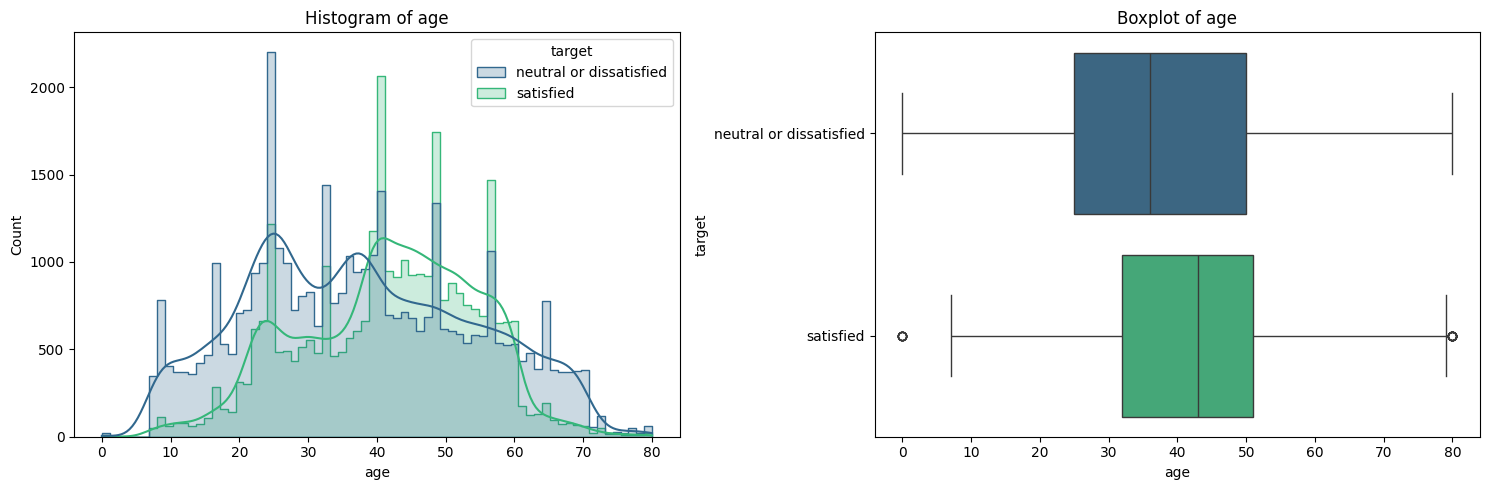

/var/folders/60/cwb977sd0snfbvkgx3p6b7m80000gn/T/ipykernel_75359/1762705317.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x=col, y='target', ax=axes[1], palette='viridis', orient='h')


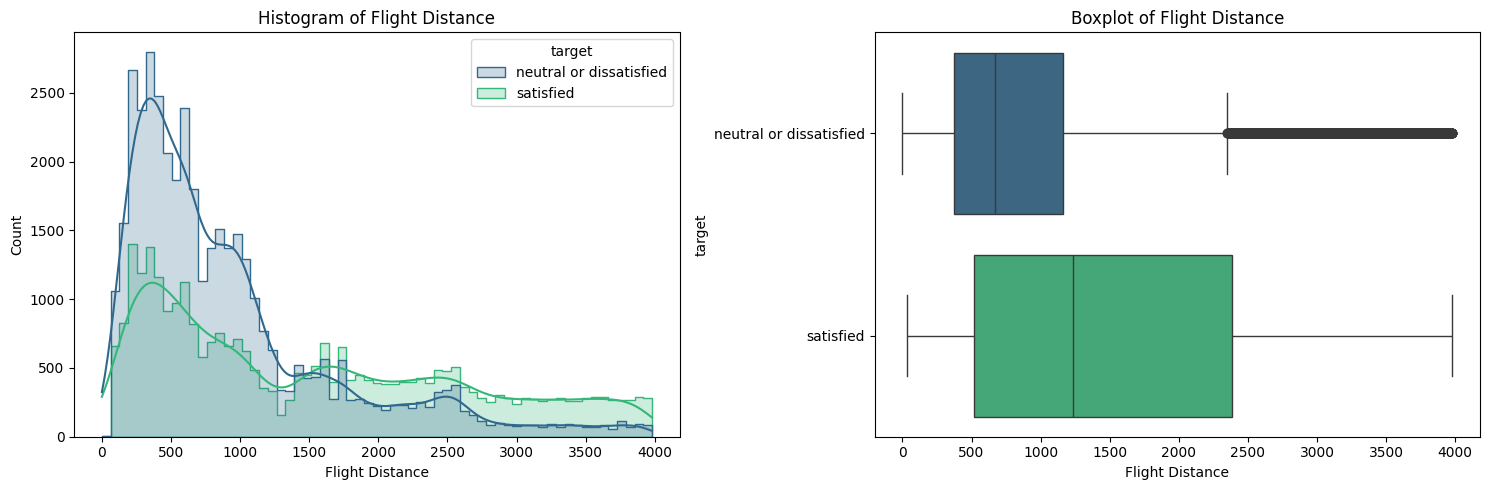

/var/folders/60/cwb977sd0snfbvkgx3p6b7m80000gn/T/ipykernel_75359/1762705317.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x=col, y='target', ax=axes[1], palette='viridis', orient='h')


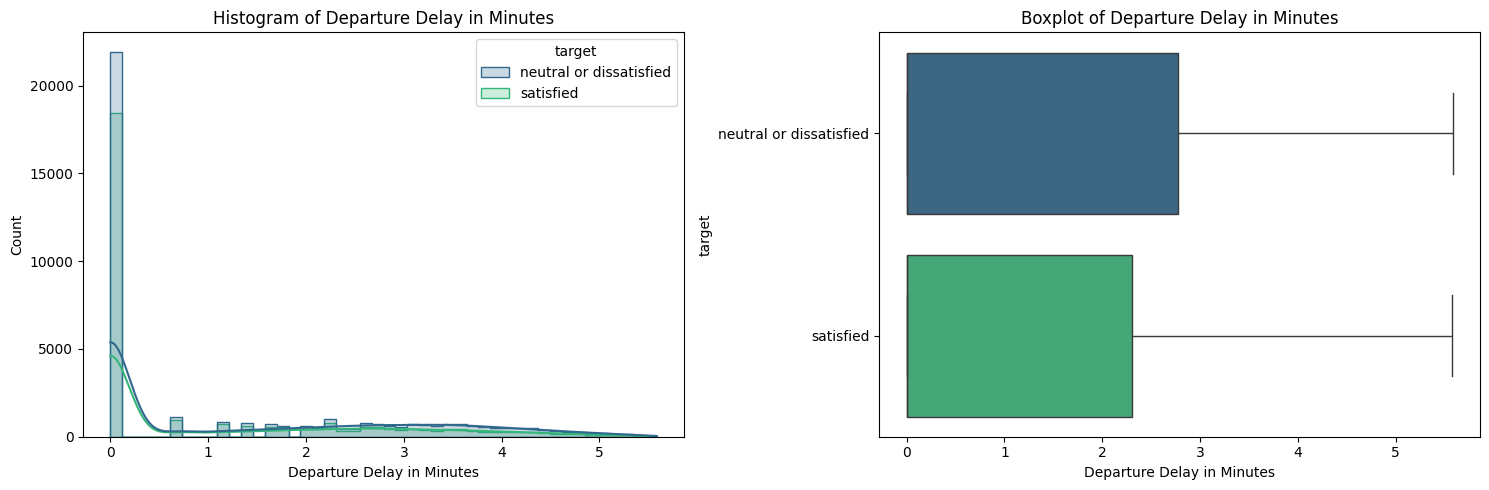

/var/folders/60/cwb977sd0snfbvkgx3p6b7m80000gn/T/ipykernel_75359/1762705317.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x=col, y='target', ax=axes[1], palette='viridis', orient='h')


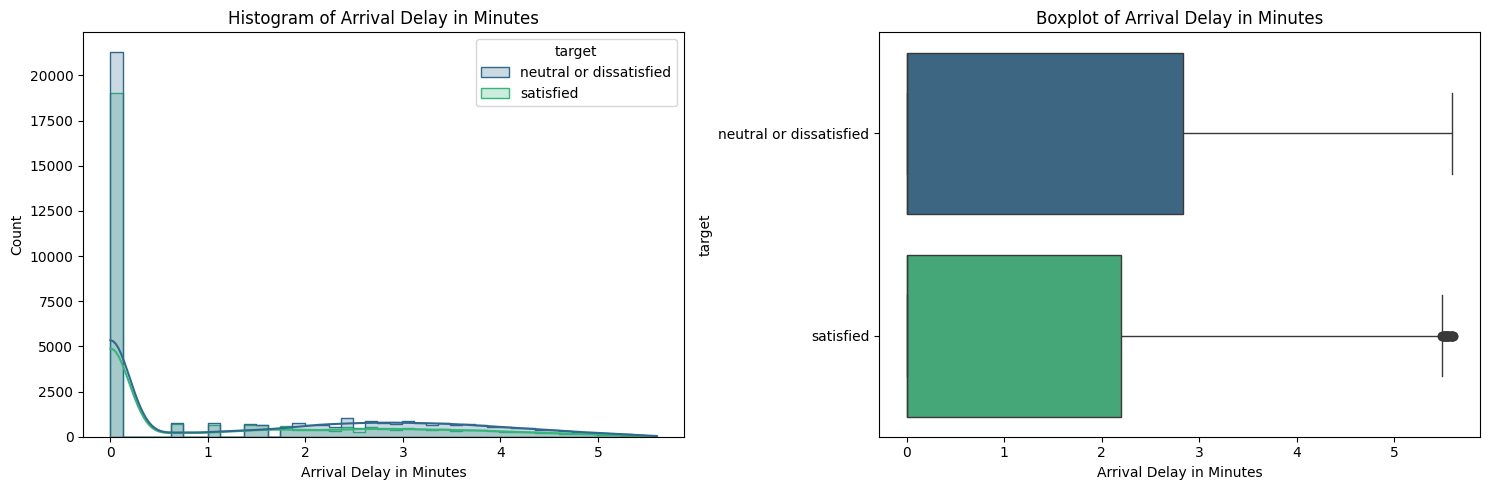

In [31]:
plot_continuous(continuous_cols, X_train, y_train)

### **Задание 10 (0.25 балла)**

Выше вы рассмотрели `boxplot` и графики распределений. Но иногда полезным оказывается `scatterplot, (pairplot)` в seabron. Проверьте, что покажет этот график в нашей задаче.

- Отобразите попарное распределение континуальных (по договоренности) признаков. Покрасьте точки на pairplot'е в соответствии с их классом.

**Примечание:**
Наблюдений много, так что отрисовка графика вполне может занять несколько минут

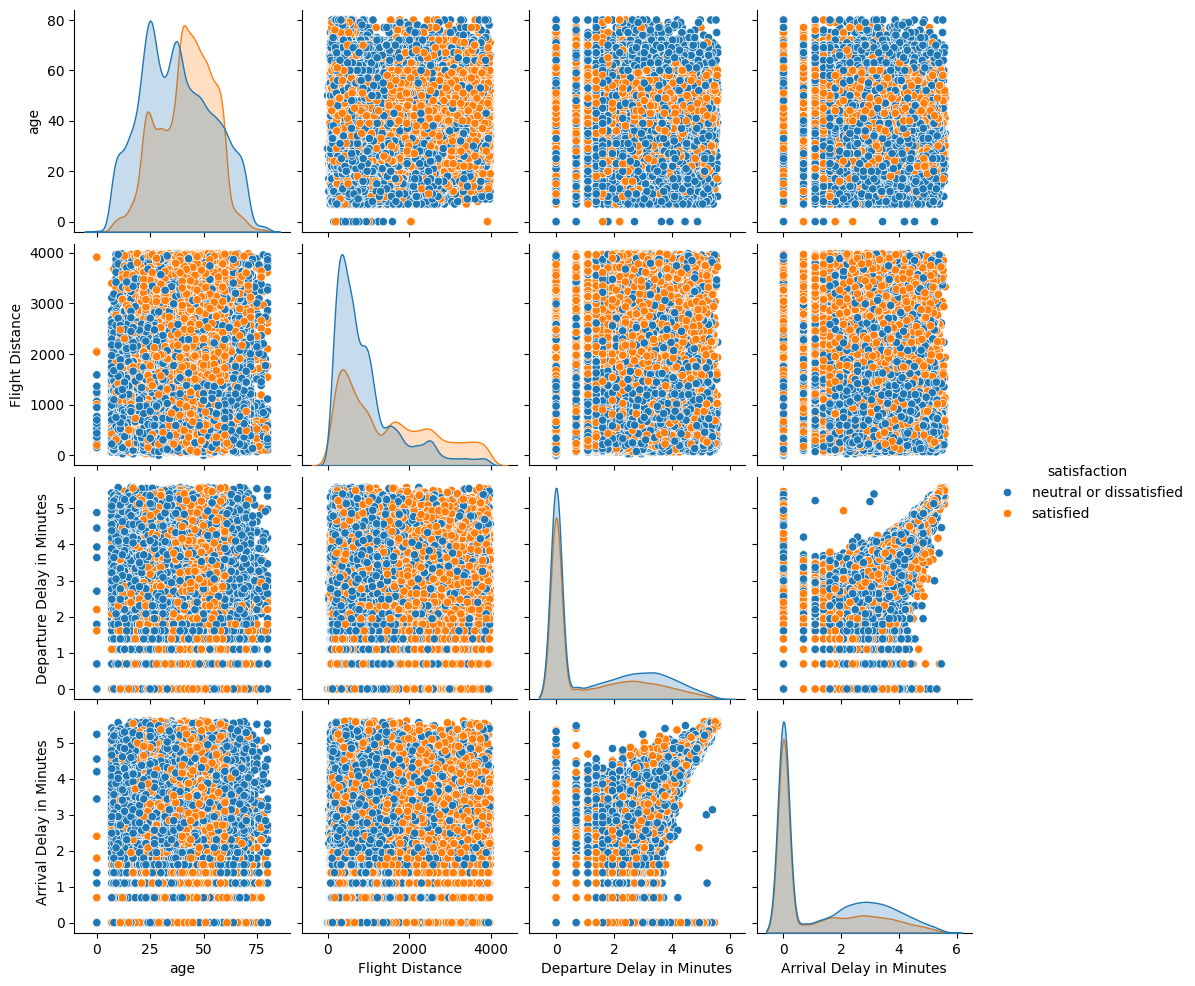

In [32]:
# Создаем временный датафрейм для отрисовки
temp_df = X_train[continuous_cols].copy()
temp_df['satisfaction'] = y_train.values

sns.pairplot(
    temp_df,
    hue='satisfaction',
    palette=['tab:blue', 'tab:orange'],
    diag_kind='kde'
)

plt.show()

# **Часть 2. Decision Tree (3 балла)**

### **Задание 11 (0.4 балла)**

Предобработайте данные для алгоритма.
- Закодируйте таргет таким образом, чтоб 'satisfied' перешел в 1, а остальные значения в 0;
- Закодируйте категориальные признаки методом OHE;

In [ ]:
# 1. Кодируем таргет
y_train_enc = y_train.map({'satisfied': 1, 'neutral or dissatisfied': 0})
y_val_enc = y_val.map({'satisfied': 1, 'neutral or dissatisfied': 0})

# 2. Кодируем категориальные признаки (OHE)
# Создаем энкодер. drop='first' удаляет первый столбец, чтобы избежать мультиколлинеарности
# sparse_output=False, чтобы получить pandas DataFrame сразу
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# satisfaction удалять не надо, он уже в y.
categorical_cols_names = ['gender', 'Customer Type', 'Type of Travel', 'class']

# Обучаем
ohe.fit(X_train[categorical_cols_names])

# Трансформируем данные
# Функция для удобства, чтобы сохранить индексы и названия колонок
def transform_ohe(df, encoder, cat_cols):
    # Получаем закодированные данные
    encoded_data = encoder.transform(df[cat_cols])
    # Получаем имена новых колонок
    encoded_cols = encoder.get_feature_names_out(cat_cols)
    # Создаем DF
    encoded_df = pd.DataFrame(encoded_data, columns=encoded_cols, index=df.index)
    # Удаляем старые колонки и добавляем новые
    return pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1)

X_train_enc = transform_ohe(X_train, ohe, categorical_cols_names)
X_val_enc = transform_ohe(X_val, ohe, categorical_cols_names)

print(f"Размерность X_train_enc: {X_train_enc.shape}")
# Проверка: все ли данные теперь числовые
assert X_train_enc.select_dtypes(include='object').empty

Размерность X_train_enc: (71395, 23)


### **Задание 12. (0.1 балла)**

- Обучите дерево решений с параметрами по умолчанию на имеющихся данных.
- Выведите `accuracy_score` для валидационной подвыборки

**Примечание**:

Здесь и далее, где вас просят что-нибудь обучить, выводите **везде** `accuracy_score` для валидационной подвыборки.

In [34]:
# Обучаем дерево с параметрами по умолчанию
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_enc, y_train_enc)

# Предсказываем и считаем accuracy на валидации
y_pred_val = dt_default.predict(X_val_enc)
acc_val = accuracy_score(y_val_enc, y_pred_val)

print(f"Accuracy on validation (dt_default): {acc_val:.4f}")

Accuracy on validation (dt_default): 0.9430


## **Анализ построенной модели**

### **Задание 13. (0.5 балла)**

- Посчитайте bias и variance для построенного дерева. Для этого проще всего вспользоваться функцией `bias_variance_decomp()` из модуля mlxtend. Используйте '0-1_loss'

In [35]:
# mlxtend лучше работает с numpy-массивами, чем с pandas DataFrame
# Используем .values для конвертации
error_dt, bias_dt, var_dt = bias_variance_decomp(
    dt_default,
    X_train_enc.values, y_train_enc.values,
    X_val_enc.values, y_val_enc.values,
    loss='0-1_loss',
    random_seed=42
)

print(f'Average expected loss: {error_dt:.4f}')
print(f'Average bias: {bias_dt:.4f}')
print(f'Average variance: {var_dt:.4f}')

Average expected loss: 0.0618
Average bias: 0.0405
Average variance: 0.0460


### **Задание 14. (0.2 балла)**

Проанализируйте структурные характеристики дерева.
- Какой глубины получилось дерево?
- Сколько в нем листьев?

In [36]:
print(f"Глубина дерева: {dt_default.get_depth()}")
print(f"Количество листьев: {dt_default.get_n_leaves()}")

Глубина дерева: 31
Количество листьев: 2099


### **Задание 15. (0.3 балла)**

Проанализируйте важность признаков, вычисляемую в дереве по построению.

- Выведите на экран barplot, демонстрирующий оценки важности признаков.
- Укажите, какие признаки оказались наиболее информативными?

Топ-5 самых важных признаков:


,Feature,Importance
9,Online boarding,0.352331
4,Inflight wifi service,0.180278
20,Type of Travel_Personal Travel,0.154575
11,Inflight entertainment,0.045442
19,Customer Type_disloyal Customer,0.031711


/var/folders/60/cwb977sd0snfbvkgx3p6b7m80000gn/T/ipykernel_75359/3805138174.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df.head(20), x='Importance', y='Feature', palette='viridis')


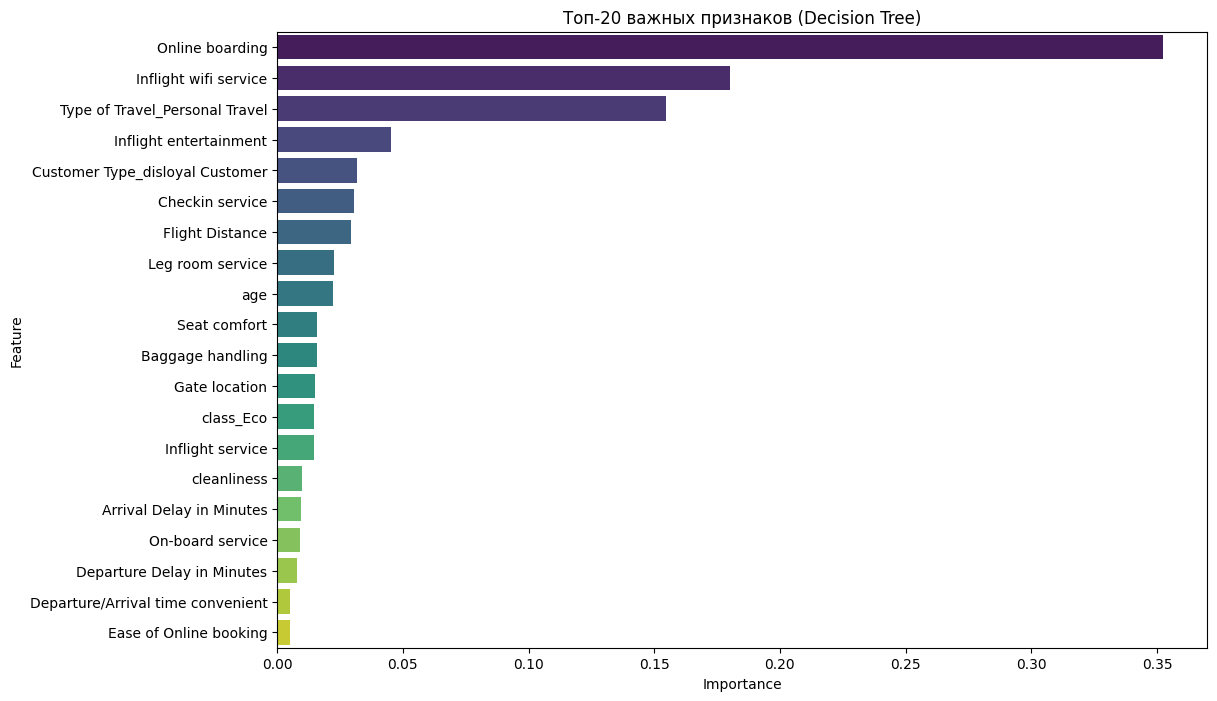

In [ ]:
# Получаем важности
importances = dt_default.feature_importances_
feature_names = X_train_enc.columns

# Создаем DataFrame для удобства
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Топ-5 самых важных признаков:")
display(feature_imp_df.head(5))

# Строим график
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_imp_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title("Топ-20 важных признаков (Decision Tree)")
plt.show()

**Анализ важности признаков:**

1.  **Доминирующие признаки:**
    Явно выделяются всего **три признака**, которые суммарно дают около **68%** вклада в построение дерева:
    *   `Online boarding` (~35%): Самый важный фактор. Видимо, удобство регистрации (или её отсутствие) задает большую часть впечатлению от полета.
    *   `Inflight wifi service` (~18%): Наличие интернета критически важно для пассажира.
    *   `Type of Travel` (~15%): Цель поездки (бизнес или личная) сильно влияет на ожидания и итоговую оценку.

2.  **Спад информативности:**
    После топ-3 идет резкий спад. `Inflight entertainment` имеет важность всего 4.5%. Это говорит о том, что если у пассажира есть Wi-Fi и он быстро зарегистрировался, то наличие фильмов на борту его волнует гораздо меньше.

3.  **Вывод:**
    Модель в основном опирается на **технологический комфорт** (регистрация, wifi) и **контекст поездки**.

### **Задание 16. (0.1 балла)**

- Постройте дерево глубины 5, используя только 2 наиболее информативных признака для предыдущего построенного дерева.

In [38]:
# 1. Берем топ-2 признака из таблицы важности
# или можно задать вручную: cols = ['Online boarding', 'Inflight wifi service'], но хардкод - это минус вайб
top_2_features = feature_imp_df.head(2)['Feature'].values
print(f"Строим дерево на признаках: {top_2_features}")

# 2. Оставляем в трейне только эти два столбца
X_train_small = X_train_enc[top_2_features]
# y_train_small такой же, как основной таргет
y_train_small = y_train_enc

# 3. Обучаем дерево глубины 5
dt_small = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_small.fit(X_train_small, y_train_small)

Строим дерево на признаках: <StringArray>
['Online boarding', 'Inflight wifi service']
Length: 2, dtype: str


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### **Задание 17. (0.15 балла)**

- С помощью graphviz визуализируйте получившееся новое дерево решений. Почему предикаты в нем не целые, а кратны 1/2?

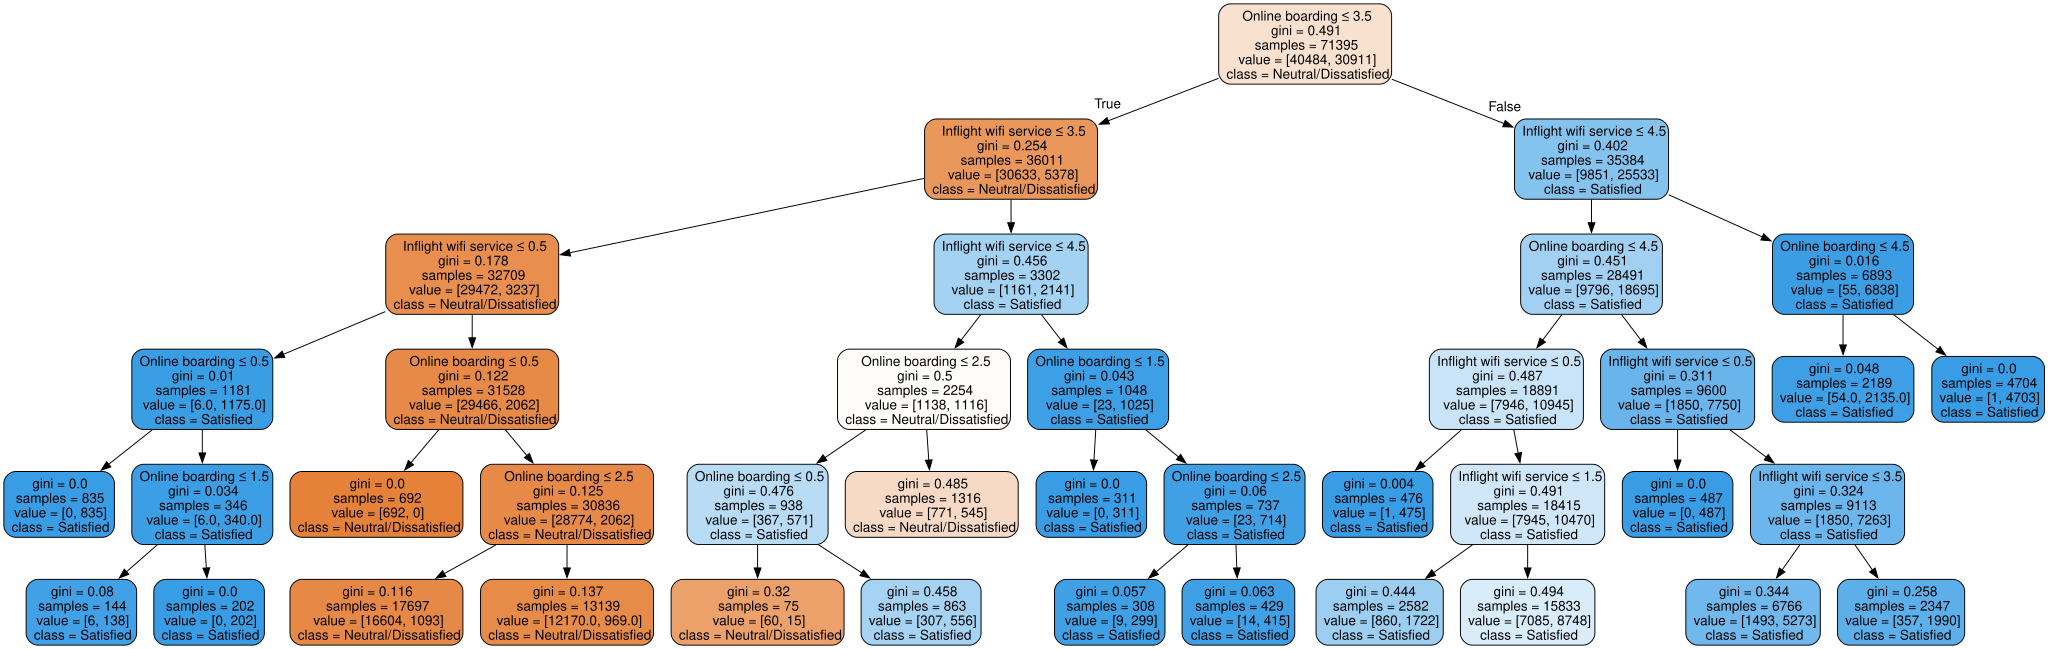

In [ ]:
dot_data = export_graphviz(dt_small, out_file=None,
                           feature_names=top_2_features,
                           class_names=['Neutral/Dissatisfied', 'Satisfied'],
                           filled=True, rounded=True,
                           special_characters=True)
graph = Source(dot_data)
display(SVG(graph.pipe(format='svg')))

Дерево из scikit-learn при разбиени использует алогоритм CART.

Алгоритм работает с признаками (даже если они целочисленные, как оценки 1-5) как с непрерывными величинами. Чтобы найти точку разбиения:

* Он сортирует уникальные значения признака.
* В качестве порога (threshold) берется среднее арифметическое между двумя соседними значениями.

*Гуглить — можно, но помните о культуре цитирования.*

Хорошо. Вот ссылка: https://scikit-learn.org/stable/modules/tree.html#tree-algorithms-id3-c4-5-c5-0-and-cart

Пункты 1.10.6:

> "scikit-learn uses an optimized version of the CART algorithm; however, the scikit-learn implementation does not support categorical variables for now."

и 1.10.7:

> "With the best splitter (default, splitter='best'),
 is found by performing a greedy exhaustive search over all available features and all possible thresholds
 (i.e. midpoints between sorted...)"

### **Задание 18. (0.25 балла)**

- Теперь отобразите его функцией `plot_tree()` из sklearn.
- Проанализируйте — ссимметричным ли получилось дерево? И хорошо ли это, или нет?

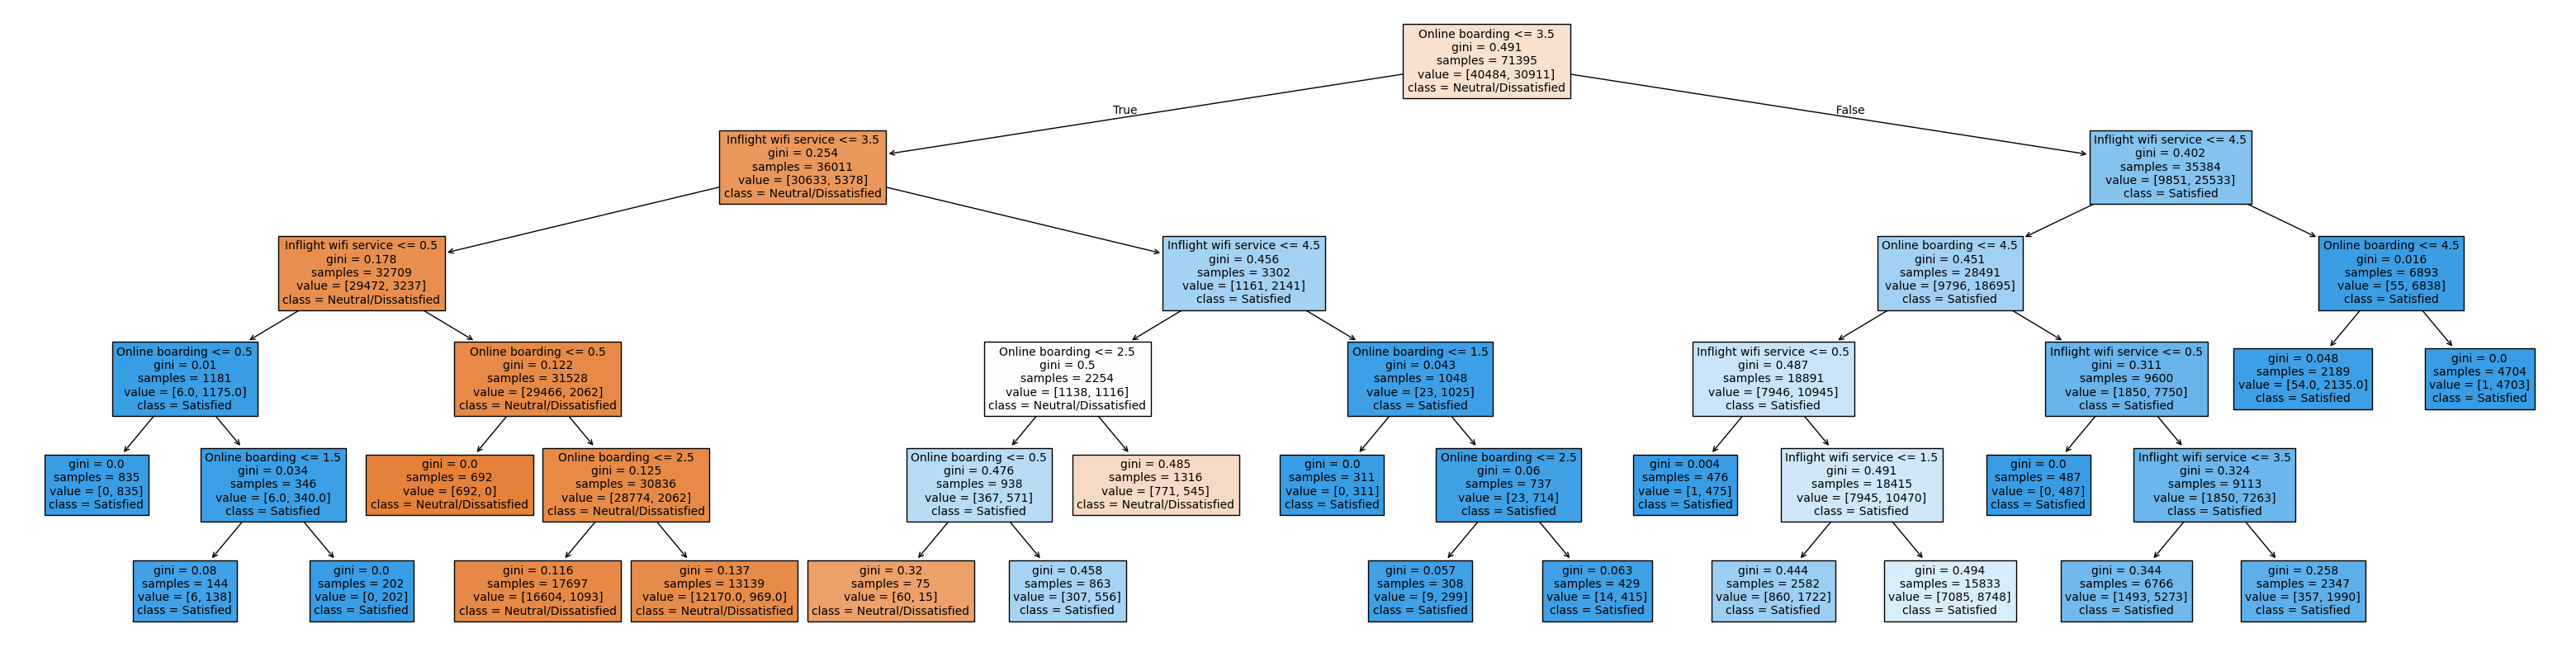

In [41]:
plt.figure(figsize=(40, 10))
plot_tree(dt_small,
          feature_names=top_2_features,
          class_names=['Neutral/Dissatisfied', 'Satisfied'],
          filled=True,
          fontsize=10)
plt.show()

 > Визуально дерево получилось **симметричным** (по глубине) — обе ветви достигают максимальной глубины 5 и имеют схожую разветвленность.

 **Хорошо это или нет?**
 В данном случае эта симметрия — скорее **минус (признак избыточности)**, чем плюс.
 *   Левая ветвь (`Online boarding <= 3.5`) решает сложную задачу разделения классов, и ее глубина оправдана.
 *   Правая ветвь (`Online boarding > 3.5`) практически во всех листьях предсказывает один и тот же класс (`Satisfied`). То, что она выросла до глубины 5, говорит о том, что алгоритм пытается уловить единичные выбросы среди довольных клиентов. Это может указывать на легкое переобучение в правой части дерева, так как логика там не меняет финального предсказания для большинства пассажиров.
 *  Идеальное дерево для этой задачи было бы явно асимметричным: глубоким слева (где сложно) и коротким справа (где решение очевидно). Так как наше дерево не остановилось справа раньше, значит, параметры регуляризации (например, min_samples_leaf или ccp_alpha) были недостаточно строгими для отсечения лишних веток.

### **Задание 19. (0.5 балла)**

- Используя функцию `plot_decision_regions()` из `mlxtend`, отобразите разделяющую поверхность получившегося дерева. Отметьте на графике только первые 100 объектов обучающей выборки

/Users/staspog/HSE/hse-ml-homework/HW_4/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


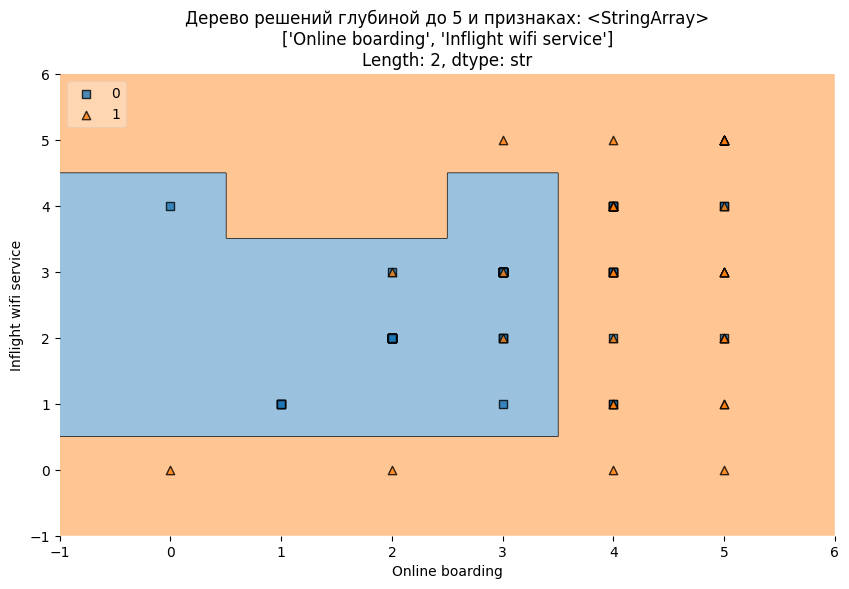

In [42]:
# Функция plot_decision_regions требует numpy массивы на вход
# Берем первые 100 объектов из того набора, на котором обучали dt_small
X_plot = X_train_small.iloc[:100].values
y_plot = y_train_small.iloc[:100].values.astype(int) # Убедимся, что таргет int

plt.figure(figsize=(10, 6))
plot_decision_regions(X=X_plot, y=y_plot, clf=dt_small, legend=2)

plt.xlabel(top_2_features[0])
plt.ylabel(top_2_features[1])
plt.title(f'Дерево решений глубиной до 5 и признаках: {top_2_features}')
plt.show()

### **Деревья решений. Теоретическая вставка**

Из лекций вам должно быть известно, что деревья решений неустойчивы даже к небольшим изменениям в обучающей выборке. Попробуем показать это!

/Users/staspog/HSE/hse-ml-homework/HW_4/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/staspog/HSE/hse-ml-homework/HW_4/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/staspog/HSE/hse-ml-homework/HW_4/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/staspog/HSE/hse-ml-homework/HW_4/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/staspog/HSE/hse-ml-homework/HW_4/venv/lib/python3.11/site-package

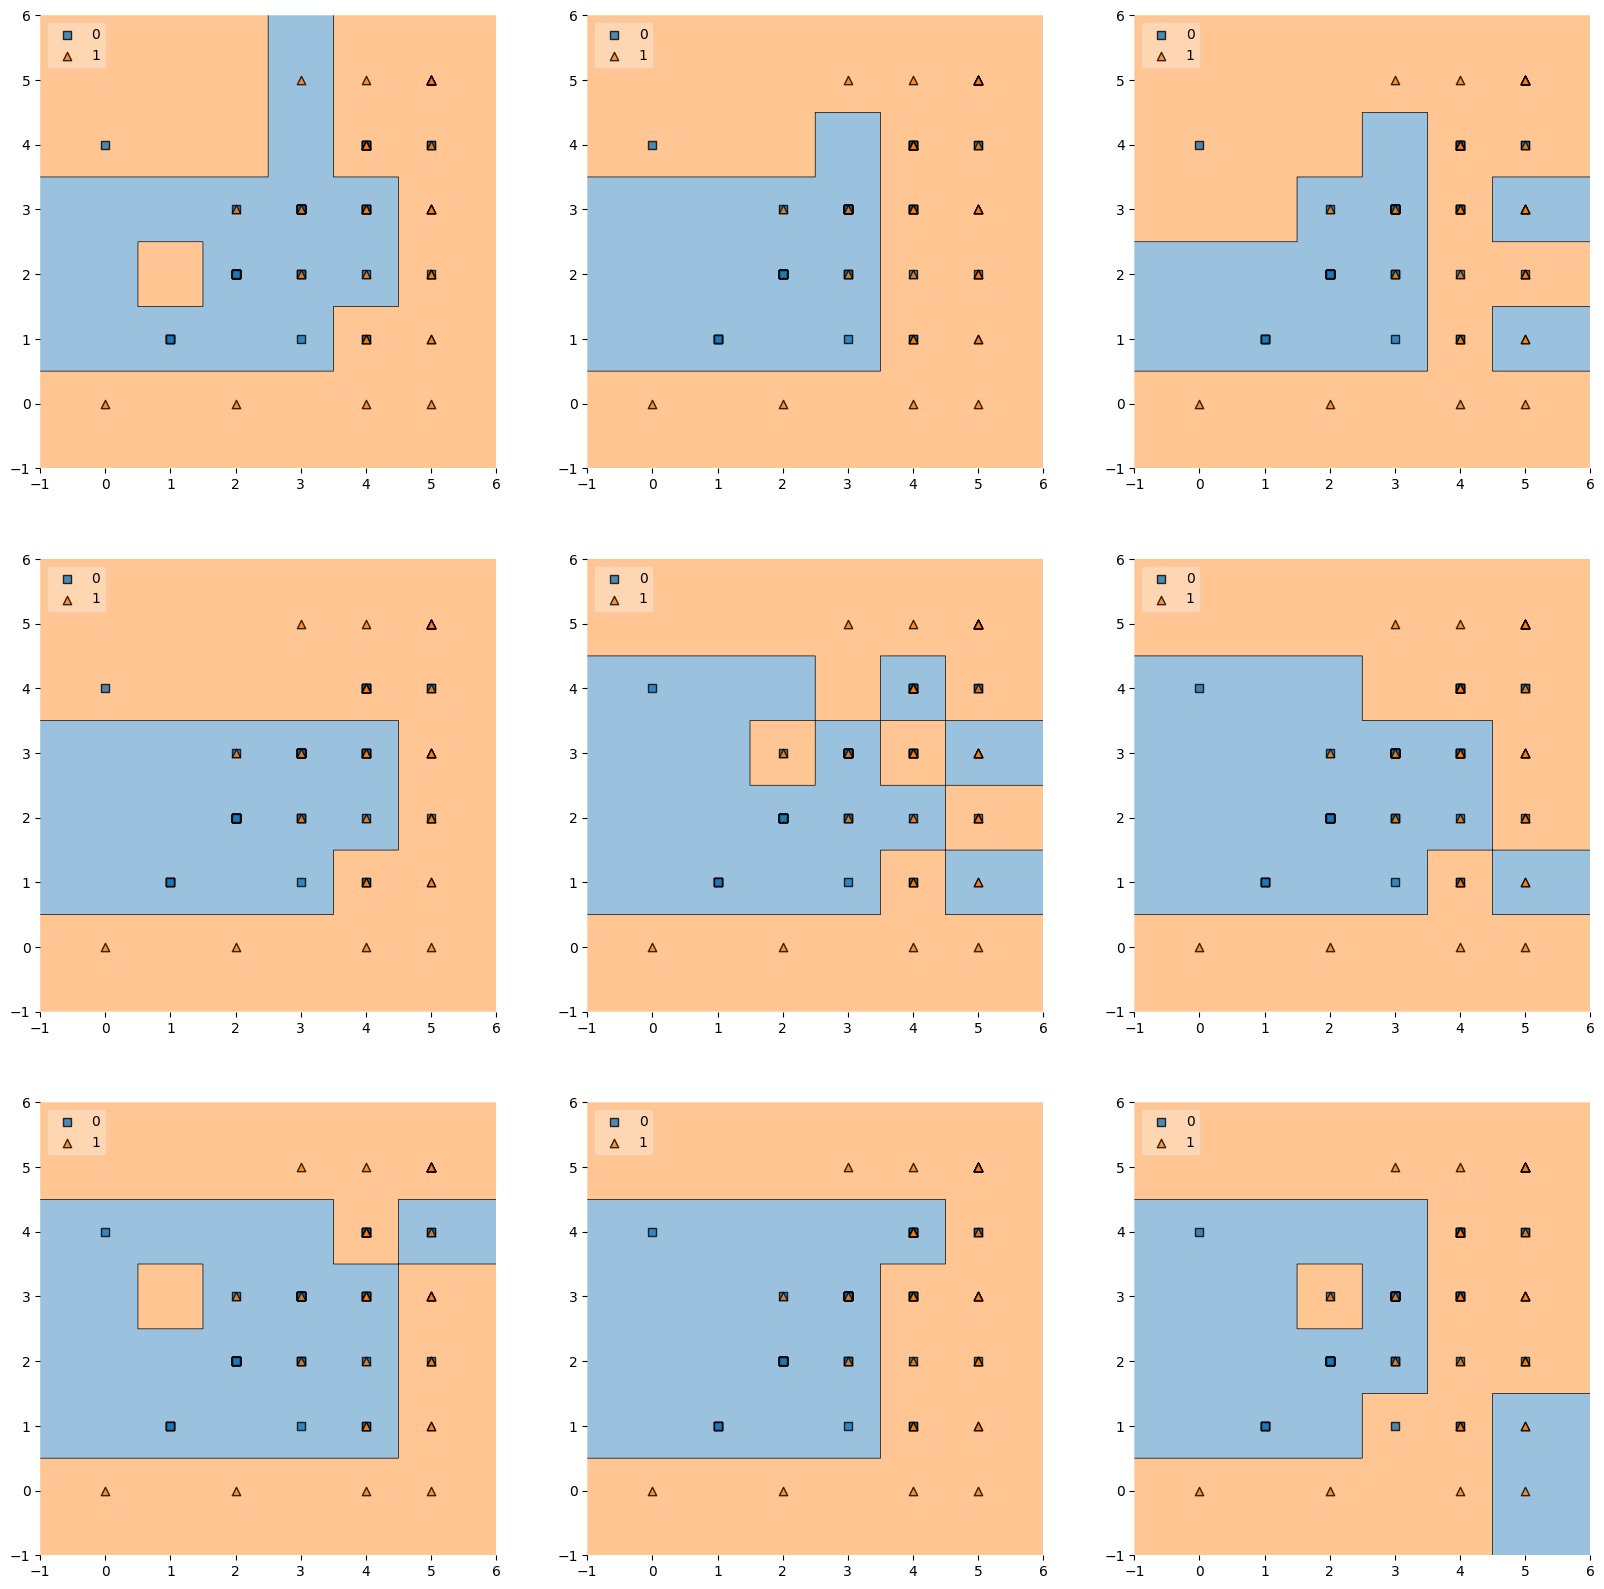

In [43]:
# замените X_train_example на вашу переменную
X_train_example = X_train_small

fig, ax = plt.subplots(3, 3, figsize=(20, 20))

for row in range(3):
    for col in range(3):
        inds = np.random.choice(X_train_example.index, size=200, replace=False)

        tree_exp = DecisionTreeClassifier(max_depth=None)

        tree_exp.fit(X_train_example.loc[inds, :], y_train_enc.loc[inds])

        plot_decision_regions(
            clf=tree_exp,
            X=X_train_example.iloc[:100, :].values,
            y=y_train_enc.iloc[:100].values.astype(int),
            ax=ax[row][col],
            legend=2
        )

plt.show()

**Смотрите как двигается гранится, а ведь мы убирали из трейна (а в нем ~80к наблюдений) всего по тысяче случайных объектов!**

Чесно говоря, почему-то не получилось продемонстрировать значенительные изменения при удалении 1000 и даже 5000 объектов, пришлось уменьшить выборку.

Помимо своей неусточивости деревья решений "славны" ещё и склонностью к переобучению. Посмотрим, можно ли увидеть это свойство на имеющихся у нас данных. Для этого будем обучать алгоритм DT на всем трейне с разной глубиной дерева и считать accuracy для теста

In [44]:
# Используем полные закодированные данные (OHE)
X_train_full = X_train_enc
y_train_full = y_train_enc
%time
depths = [2, 3, 5, 10, 15, 20, 25, 32, 50, 64, 75, 100]

accuracies_train = []
accuracies_test = []
for max_depth in depths:
    DT = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    DT.fit(X_train_enc, y_train)
    y_predicted_train = DT.predict(X_train_enc)
    y_predicted_val = DT.predict(X_val_enc)
    accuracies_train.append(accuracy_score(y_train, y_predicted_train))
    accuracies_test.append(accuracy_score(y_val, y_predicted_val))

CPU times: user 2 μs, sys: 1e+03 ns, total: 3 μs
Wall time: 11 μs


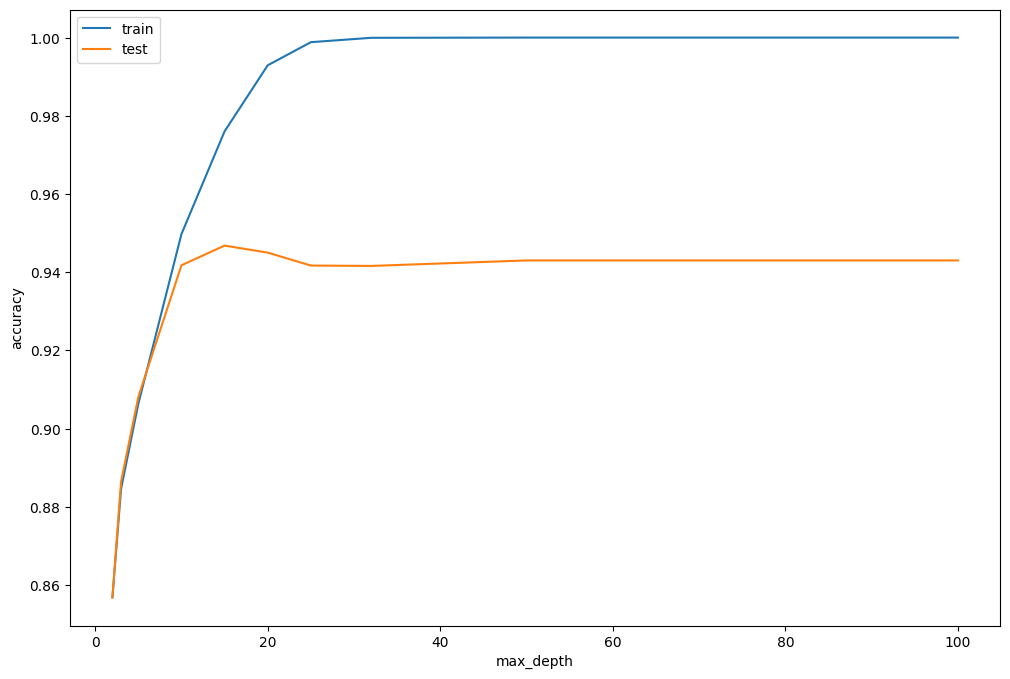

In [45]:
plt.figure(figsize=(12, 8))
plt.plot(depths, accuracies_train, depths, accuracies_test)
plt.legend(['train', 'test'])
plt.ylabel('accuracy')
plt.xlabel('max_depth')
plt.show()

Нам повезло выйти на ассимптоту на тесте. Однако так бывает далеко не всегда. Так что подбирать гипрепараметры для деревьев решений стоит осторожно

## **Возвращение к задаче**

### **Задание 20. (0.4 балла)**

- На кроссвалидации подберите оптимальные гиперпараметры для дерева решений *(по данным со всеми признаками -- не на модельном примере из теоретической вставки)*.
- Удалось ли улучшить качество предсказаний подбором гиперпараметров?

In [46]:
# Определяем сетку гиперпараметров
param_grid = {
    'max_depth': [10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Создаем экземпляр GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Обучаем
grid_search_dt.fit(X_train_enc, y_train_enc)

# Выводим лучшие параметры
print(f"Лучшие параметры: {grid_search_dt.best_params_}")
print(f"Лучший скор на кросс-валидации: {grid_search_dt.best_score_:.4f}")

# Оцениваем лучшую модель на валидации
best_dt = grid_search_dt.best_estimator_
y_pred_val_best = best_dt.predict(X_val_enc)
acc_val_best = accuracy_score(y_val_enc, y_pred_val_best)

print(f"Accuracy на валидации (dt_default): {acc_val:.4f}")
print(f"Accuracy на валидации (best_dt): {acc_val_best:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/Users/staspog/HSE/hse-ml-homework/HW_4/venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Лучшие параметры: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 20}
Лучший скор на кросс-валидации: 0.9498
Accuracy на валидации (dt_default): 0.9430
Accuracy на валидации (best_dt): 0.9506


### **Задание 21. (0.1 балла)**

- Сохраните лучшее дерево в pickle

*Мы просим это сделать, чтобы вы в случае чего не тратили время на переобучение, а могли банально подгрузить из файла*

In [47]:
with open('DT.pkl', 'wb') as f:
    pickle.dump(best_dt, f)

# **Часть 3. Random Forest (4.25 балла)**

### **Задание 22. (0.05 балла)**
- Обучите случайный лес с параметрами по умолчанию

In [48]:
# Обучаем Random Forest с параметрами по умолчанию
rf_default = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_default.fit(X_train_enc, y_train_enc)

# Оцениваем качество
y_pred_val_rf = rf_default.predict(X_val_enc)
acc_val_rf = accuracy_score(y_val_enc, y_pred_val_rf)

print(f"Accuracy on validation (Random Forest default): {acc_val_rf:.4f}")

Accuracy on validation (Random Forest default): 0.9614


### **Задание 23. (0.15 балла)**
- Выведите калибровочную кривую для полученного ансамбля

<Figure size 1000x600 with 0 Axes>

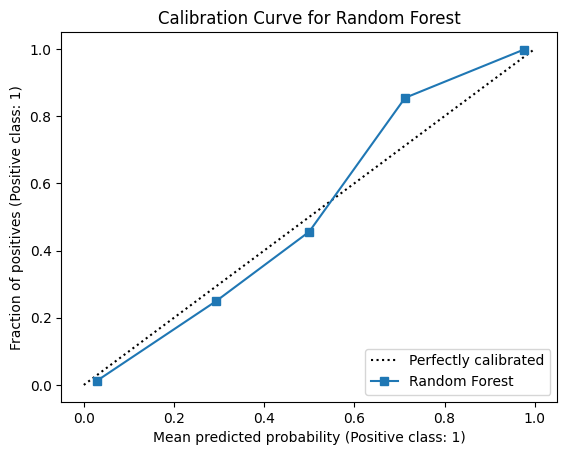

In [49]:
plt.figure(figsize=(10, 6))
CalibrationDisplay.from_estimator(rf_default, X_val_enc, y_val_enc, n_bins=5, name='Random Forest')
plt.title("Calibration Curve for Random Forest")
plt.show()

Похоже, мы немного недооцениваем высокие вероятности

<img src='https://habrastorage.org/r/w1560/getpro/habr/upload_files/510/4e0/63b/5104e063b62bd0ac6b87da44a3034aa5.png'>

Изображение взято из статьи ["predict_proba в Python не прогнозирует вероятности (и как с этим бороться)"](https://habr.com/ru/company/otus/blog/573924/) с Хабра

### **Задание 24. (0.4 балла)**

- Вспомните (или выведите), корректно ли деревья предсказывают вероятности?

Деревья решений **некорректно** предсказывают вероятности.
1.  Предсказанная вероятность в листе — это доля объектов положительного класса, попавших в этот лист при обучении.
2.  Деревья стремятся минимизировать impurity, делая листья максимально чистыми (состоящими из объектов одного класса). Из-за этого вероятности часто смещаются к краям отрезка [0, 1] (то есть ближе к 0 или 1).
3.  Это приводит к тому, что распределение предсказанных вероятностей не соответствует реальной частоте появления класса, что мы и видим на калибровочных кривых (S-образная форма или смещение).

### **Задание 25. (0.15 балла)**
- Обучите логистическую регрессию так, чтобы она сошлась
- Отобразите её калибровочную кривую

Accuracy on validation (Logistic Regression): 0.8756


<Figure size 1000x600 with 0 Axes>

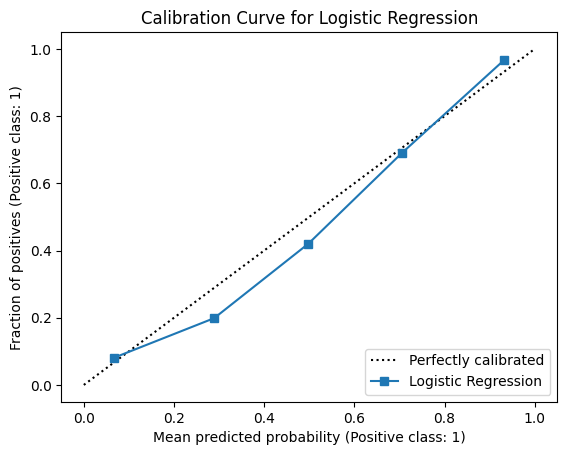

In [50]:
# Увеличиваем max_iter, чтобы алгоритм успел сойтись
lr = LogisticRegression(max_iter=3000, random_state=42)
lr.fit(X_train_enc, y_train_enc)

y_pred_val_lr = lr.predict(X_val_enc)
acc_val_lr = accuracy_score(y_val_enc, y_pred_val_lr)
print(f"Accuracy on validation (Logistic Regression): {acc_val_lr:.4f}")

plt.figure(figsize=(10, 6))
CalibrationDisplay.from_estimator(lr, X_val_enc, y_val_enc, n_bins=5, name='Logistic Regression')
plt.title("Calibration Curve for Logistic Regression")
plt.show()

Мы немного переоцениваем предсказанные низкие вероятности

### **Задание 26. (0.2 балла)**
- Покажите, почему считается, что логистическая регрессия корректно предсказывает вероятности?

Логистическая регрессия оптимизирует функционал **Log Loss**, который напрямую связан с правдоподобием.
$$ L(w) = - \sum_{i=1}^N (y_i \log(p_i) + (1 - y_i) \log(1 - p_i)) $$
где $p_i = \sigma(w^T x_i)$.
Минимизация этого функционала заставляет модель выдавать оценки $p_i$, которые соответствуют истинным условным вероятностям классов $P(y=1|x)$. Поэтому, если предпосылки модели верны (линейная разделимость в пространстве признаков), логистическая регрессия из коробки дает хорошо откалиброванные вероятности (калибровочная кривая будет близка к диагонали).

### **Задание 27. (0.35 балла)**

Предлагаем вам попробовать откалибровать вероятности обученного случайного леса!

- Откалибруйте вероятности, при помощи логистической и изотонической регрессий.
- Интерпретируйте полученные результаты

In [51]:
from sklearn.calibration import CalibratedClassifierCV

In [ ]:
# 1. Sigmoid (Logistic) calibration
rf_sigmoid = CalibratedClassifierCV(estimator=RandomForestClassifier(random_state=42, n_jobs=-1), method='sigmoid', cv=3)
rf_sigmoid.fit(X_train_enc, y_train_enc)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'


In [53]:
# 2. Isotonic calibration
rf_isotonic = CalibratedClassifierCV(estimator=RandomForestClassifier(random_state=42, n_jobs=-1), method='isotonic', cv=3)
rf_isotonic.fit(X_train_enc, y_train_enc)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'

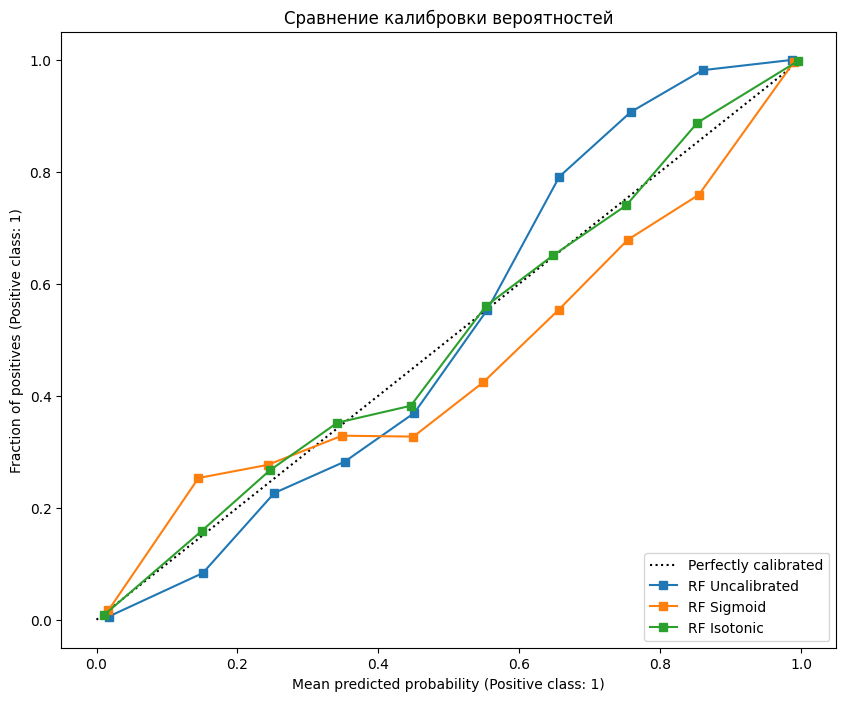

In [54]:
fig, ax = plt.subplots(figsize=(10, 8))
CalibrationDisplay.from_estimator(rf_default, X_val_enc, y_val_enc, n_bins=10, name='RF Uncalibrated', ax=ax)
CalibrationDisplay.from_estimator(rf_sigmoid, X_val_enc, y_val_enc, n_bins=10, name='RF Sigmoid', ax=ax)
CalibrationDisplay.from_estimator(rf_isotonic, X_val_enc, y_val_enc, n_bins=10, name='RF Isotonic', ax=ax)
plt.title("Сравнение калибровки вероятностей")
plt.show()

**Интерпретация результатов:**
*   Кривая для **неоткалиброванного RF** обычно имеет S-образную форму, как мы видели ранее, что говорит о том, что модель слишком уверена в своих предсказаниях.
*   **Sigmoid (Logistic) calibration** сглаживает предсказания, приближая кривую к диагонали. Это параметрический метод, работающий хорошо, если искажение имеет сигмоидальную форму.
*   **Isotonic calibration** (непараметрический метод) подстраивается под данные более гибко (кусочно-постоянная монотонная функция). При достаточном количестве данных она часто дает лучшую калибровку, идеально ложась на диагональ.
*   Визуально мы видим, что кривые `Sigmoid` и `Isotonic` в среднем лежат гораздо ближе к идеальной диагонали ("Perfectly calibrated"), чем исходная кривая RF.

### **Задание 28. (0.2 балла)**
- Опишите другие возвожные подходы к калибровке вероятностей (со ссылками на источники)

1.  **Platt Scaling (Sigmoid Calibration):** То, что мы использовали выше (`method='sigmoid'`). Обучает логистическую регрессию поверх выходов модели. [Original Paper (Platt, 1999)](https://www.cs.colorado.edu/~mozer/Teaching/syllabi/6622/papers/Platt1999.pdf)
2.  **Isotonic Regression:** То, что мы использовали выше (`method='isotonic'`). Минимизирует MSE при условии монотонности функции калибровки. [Zadrozny & Elkan, 2002](https://dl.acm.org/doi/10.1145/775047.775151)
3.  **Beta Calibration:** Использует Бета-распределение для калибровки. Лучше подходит для случаев, когда калибровочная кривая не S-образная. [Kull et al., 2017](https://fail.ZO/papers/beta-calibration-electronic.pdf)
4.  **Venn-Abers Predictors:** Метод, основанный на индуктивной конформной предикции, который дает интервальные оценки вероятностей. [Vovk et al., 2015](https://arxiv.org/abs/1211.0025)

С этим я попросил помочь гемини. Спросил у него, "Какие сущетствуют наиболее популярные способы калибровки вероятностей? В каких случаях они используются? В каких научных работах они были найдены или исследованы (ссылки)?"

### **Задание 29. (0.5 баллa)**

Проанализируйте лес.
- Посчитайте разброс и смещение полученного случайного леса (до калибровки).
- Оличаются ли они от полученных для дерева решений?
- Соответствуют ли полученные на реальных данных отличия (//совпадения) от тех, что должны быть в теории? По каким причинам?

In [55]:
# Считаем bias-variance для RF (rf_default)
# для RF это может работать долго из-за бутстрапа внутри функции разложения
# Уменьшим num_rounds для ускорения (по дефолту 200, поставим 30, чтобы было побыстрее
error_rf, bias_rf, var_rf = bias_variance_decomp(
    rf_default,
    X_train_enc.values, y_train_enc.values,
    X_val_enc.values, y_val_enc.values,
    loss='0-1_loss',
    random_seed=42,
    num_rounds=30
)

print(f'RF - Average expected loss: {error_rf:.4f}')
print(f'RF - Average bias: {bias_rf:.4f}')
print(f'RF - Average variance: {var_rf:.4f}')

print("\n")
print(f'DT - Average bias: {bias_dt:.4f} из задания 13')
print(f'DT - Average variance: {var_dt:.4f} из задания 13')

RF - Average expected loss: 0.0408
RF - Average bias: 0.0396
RF - Average variance: 0.0088


DT - Average bias: 0.0405 из задания 13
DT - Average variance: 0.0460 из задания 13


1.  **Разброс (Variance):**
    *   **DT:** 0.0460
    *   **RF:** 0.0088
    *   **Вывод:** Разброс уменьшился более чем в **5 раз**. Это значительное улучшение. Одиночное дерево очень чувствительно к обучающей выборке. Случайный лес усредняет ответы множества таких чувствительных деревьев, и итоговый ответ становится очень устойчивым. Шум в предсказаниях отдельных деревьев взаимоуничтожается.

2.  **Смещение (Bias):**
    *   **DT:** 0.0405
    *   **RF:** 0.0396
    *   **Вывод:** Смещение осталось практически **на том же уровне**. Это тоже полностью соответствует теории. Деревья в случайном лесу строятся глубокими (как и одиночное дерево), поэтому они хорошо подстраиваются под сложные зависимости в данных (низкое смещение). Бэггинг не исправляет систематические ошибки моделей, оно борется только с хаотичными ошибками.

3.  **Общая ошибка (Expected Loss):**
    *   **DT:** ~0.0618 (из задания 13)
    *   **RF:** 0.0408
    *   **Вывод:** Общее качество модели выросло (ошибка упала) исключительно за счет подавления дисперсии.


> Результаты полностью соответствуют теоретическим ожиданиям от алгоритма, на котором основан Random Forest:
> 1.  **Variance снизился (0.0460 -> 0.0088).** Это происходит за счет усреднения ответов множества некоррелированных деревьев. Если ошибки отдельных деревьев случайны и независимы, их усреднение стремится к нулю.
> 2.  **Bias не изменился (0.0405 -> 0.0396).** Ансамбль сохраняет сложность и гибкость базовых алгоритмов. Поскольку базовые деревья в лесу строятся глубокими и не урезаются, сам лес также имеет низкое смещение.
>
> **Заключение:** Случайный лес позволил нам сохранить высокую точность подгонки под данные (как у одного дерева), но сделал модель стабильной и устойчивой к выбросам и шуму, устранив главную проблему решающих деревьев — высокий разброс.

### **Задание 30. (0.5 баллa)**

- Вычислите разложение ошибки для логистической регрессии (ванильной, которую вы обучили для решения задачи в задании 25, а не той, что использовали для калибровки)
- Сравните полученные результаты с предыдущими.
- Объясните природу этих результатов

In [56]:
error_lr, bias_lr, var_lr = bias_variance_decomp(
    lr,
    X_train_enc.values, y_train_enc.values,
    X_val_enc.values, y_val_enc.values,
    loss='0-1_loss',
    random_seed=42,
    num_rounds=30
)

print(f'LR - Average expected loss: {error_lr:.4f}')
print(f'LR - Average bias: {bias_lr:.4f}')
print(f'LR - Average variance: {var_lr:.4f}')

/Users/staspog/HSE/hse-ml-homework/HW_4/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/staspog/HSE/hse-ml-homework/HW_4/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https:/

LR - Average expected loss: 0.1243
LR - Average bias: 0.1246
LR - Average variance: 0.0041


### **1. Анализ полученных метрик**

*   **Average Expected Loss (0.1243):** Общая ошибка модели составляет 12.4%. Это значительно хуже, чем у Decision Tree (6.2%) и Random Forest (4.1%). Логистическая регрессия проигрывает древесным алгоритмам на этой задаче.
*   **Average Bias (0.1246):** Очень высокое смещение. Оно составляет практически 100% от всей ошибки модели.
*   **Average Variance (0.0041):** низкий разброс. Он даже ниже, чем у Случайного леса (0.0088), и на порядок ниже, чем у одиночного дерева (0.0460).

### **2. Сравнение с предыдущими результатами**

*   **LR vs DT/RF:**
    *   У древесных моделей (DT и RF) **низкое смещение**, но более высокий разброс. Они способны выучить сложную структуру данных.
    *   У линейной модели (LR) **высокое смещение**, но минимальный разброс. Она слишком проста для этих данных.

### **3. Почему так?**

Такие результаты — иллюстрация **Bias-Variance Tradeoff** для линейных моделей:

1.  **Причина Высокого Смещения:**
    Логистическая регрессия — это **линейный классификатор**. Она пытается разделить классы ("Satisfied" vs "Neutral/Dissatisfied") одной гтперплоскостью.
    Однако данные о полетах содержат сложные нелинейные зависимости. Линейная модель физически не может изогнуть свою разделяющую поверхность, чтобы описать эти закономерности, поэтому она ошибается.

2.  **Причина Низкого Разброса:**
    Линейная модель очень не гибкая. У неё мало степеней свободы (только веса при признаках). Даже если мы будем менять обучающую выборку (как это делает `bias_variance_decomp` с помощью бутстрапа), оптимальная гиперплоскость будет поворачиваться совсем чуть-чуть. Модель очень стабильна и не реагирует на шум в данных, в отличие от дерева решений, которое может перестроиться из-за пары новых точек.

### **Задание 31. (0.8 баллa)**

- Попробуйте подобрать оптимальные гиперпараметры леса, используя [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html).

**Важно:**  

Хотя бы один из гиперпараметров перебирайте из распределения (например, `uniform` из `scipy.stats`)

In [ ]:
from scipy.stats import randint

# Определяем пространство поиска
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}

rs_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rs_rf.fit(X_train_enc, y_train_enc)

print(f"Лучшие параметры RF: {rs_rf.best_params_}")
print(f"Лучший скор CV: {rs_rf.best_score_:.4f}")

best_rf = rs_rf.best_estimator_
y_pred_val_best_rf = best_rf.predict(X_val_enc)
print(f"Validation Accuracy (Best RF): {accuracy_score(y_val_enc, y_pred_val_best_rf):.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Лучшие параметры RF: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 463}
Лучший скор CV: 0.9604
Validation Accuracy (Best RF): 0.9619


## **Случайный лес. Вставка теории**

На модельном примере посмотрим, склонен ли случайный лес к переобучению с ростом числа деревьев в композиции.

Возьмем 4 полезных признака из одного из предыдщущих заданий, напоминающих теорию

In [58]:
# замените X_train_enc на ваш трейн

cols_for_RF = ['age', 'Flight Distance', 'Online boarding', 'Inflight wifi service']
X_train_RF = X_train_enc[cols_for_RF]
# а тест нам не понадобится, ведь можно получить OOB-estimate ошибки

clf = RandomForestClassifier(warm_start=True, oob_score=True, random_state=42)
errors = []

for n_estimators in range(1, 251, 5):
    clf.set_params(n_estimators=n_estimators)
    clf.fit(X_train_RF, y_train)

    errors.append(1 - clf.oob_score_)

/Users/staspog/HSE/hse-ml-homework/HW_4/venv/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/staspog/HSE/hse-ml-homework/HW_4/venv/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/staspog/HSE/hse-ml-homework/HW_4/venv/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/staspog/HSE/hse-ml-homework/HW_4/venv/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/stasp

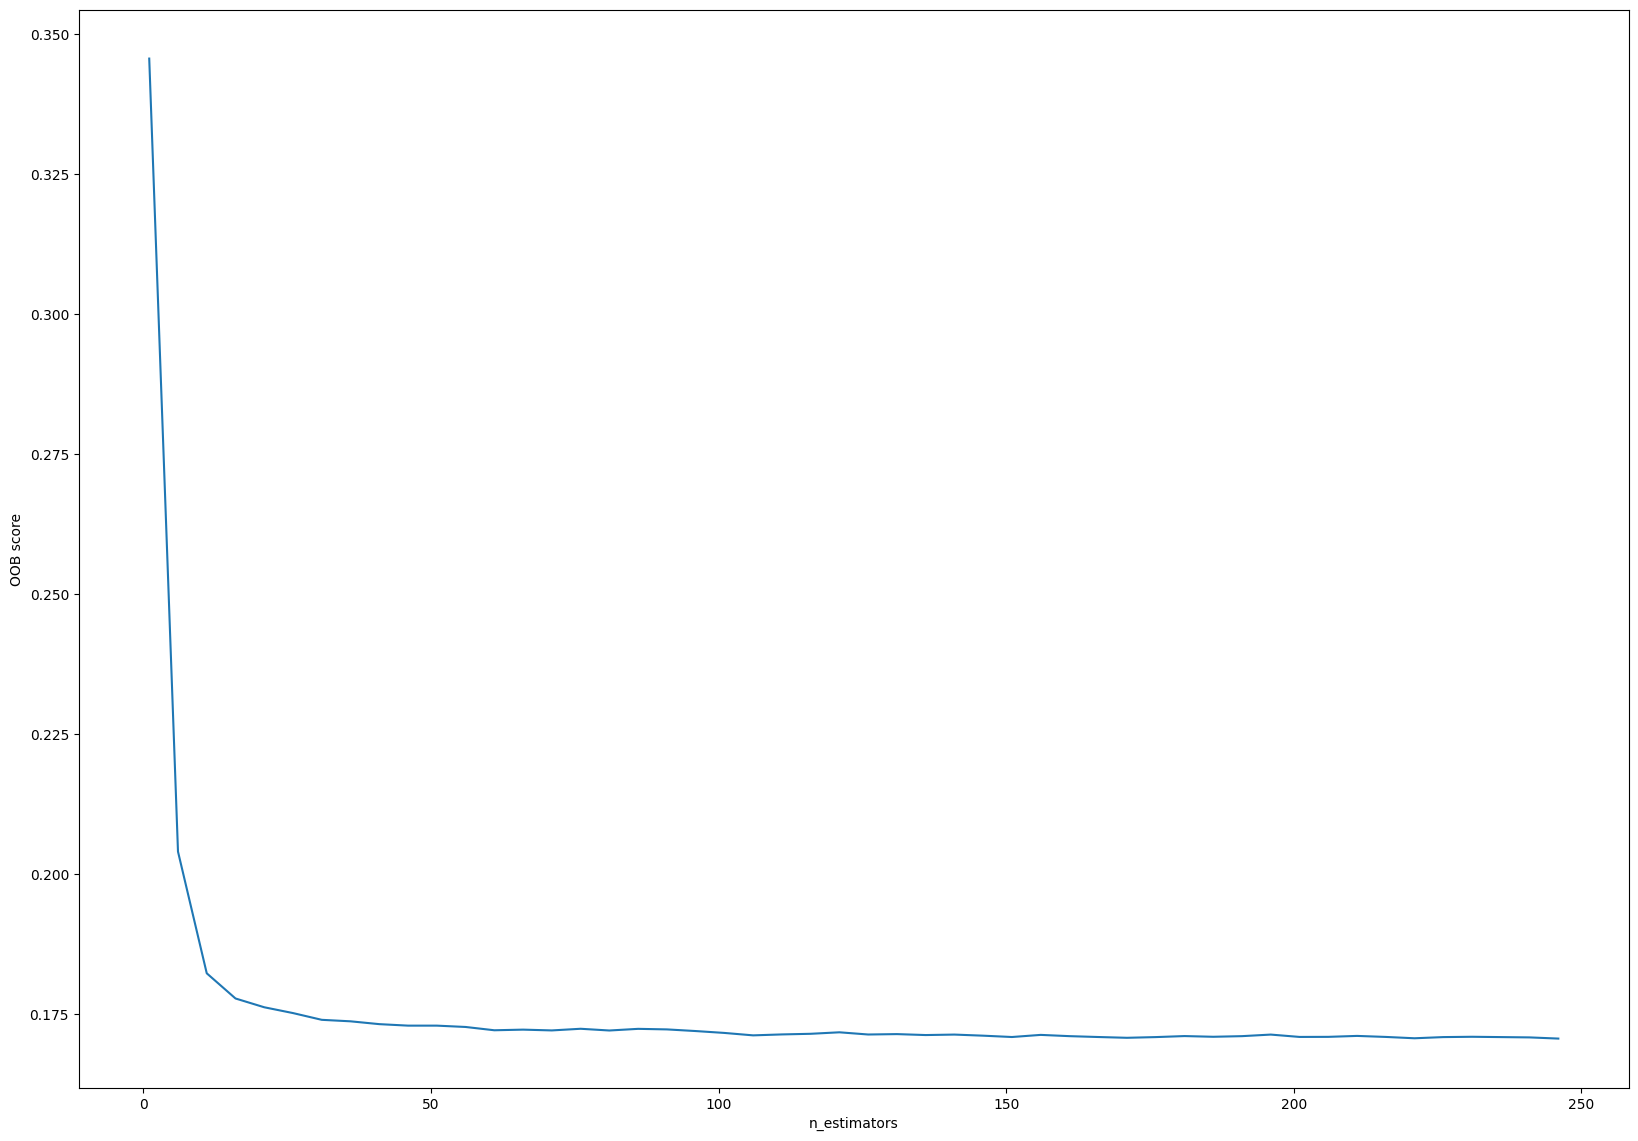

In [59]:
plt.figure(figsize=(20, 14))
plt.plot(range(1, 251, 5), errors)

plt.xlabel('n_estimators')
plt.ylabel('OOB score')
plt.show()

**Дисклеймер**: отсутствие переобучения с ростом числа деревьев вовсе не означает, что сама модель случайного леса не может быть переобучена. Базовые деревья такой композиции могут переобучаться. Значит, и вся композиция вполне способна оказаться переобученной

## **Возвращение к задаче**

### **Задание 32. (0.6 баллa)**

- Отобразите`feature_importances_` вашего лучшего случайного леса
- Сравните важности признаков для дерева решений и для случайного леса. Постройте диаграмму


In [60]:
# Получаем важности для RF
importances_rf = best_rf.feature_importances_
feature_names = X_train_enc.columns

feature_imp_rf_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_rf
}).sort_values(by='Importance', ascending=False)

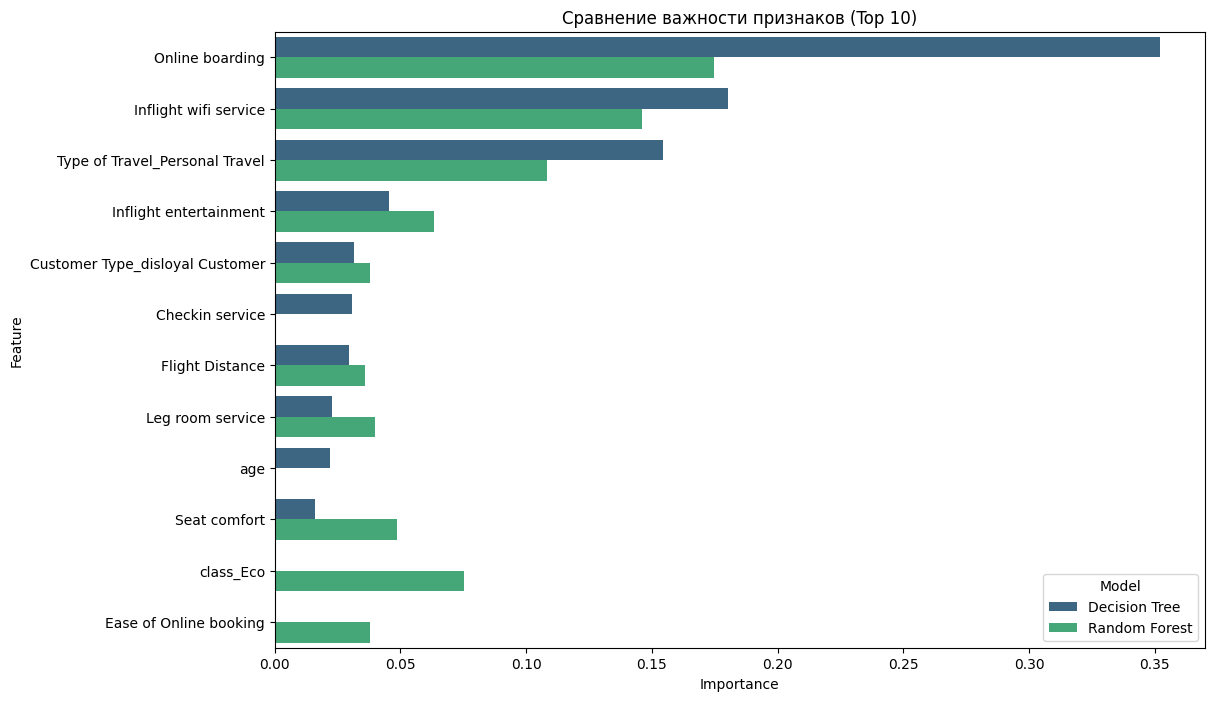

Топ-5 RF:


,Feature,Importance,Model
9,Online boarding,0.174757,Random Forest
4,Inflight wifi service,0.146143,Random Forest
20,Type of Travel_Personal Travel,0.108359,Random Forest
21,class_Eco,0.075226,Random Forest
11,Inflight entertainment,0.063498,Random Forest


In [61]:
# Строим сравнительную диаграмму
# Объединим с данными DT из задания 15 (feature_imp_df)
feature_imp_df['Model'] = 'Decision Tree'
feature_imp_rf_df['Model'] = 'Random Forest'

combined_imp = pd.concat([feature_imp_df.head(10), feature_imp_rf_df.head(10)])

plt.figure(figsize=(12, 8))
sns.barplot(data=combined_imp, y='Feature', x='Importance', hue='Model', palette='viridis')
plt.title("Сравнение важности признаков (Top 10)")
plt.show()

print("Топ-5 RF:")
display(feature_imp_rf_df.head(5))

### **Задание 33. (0.1 баллa)**

- Случайный лес, дающий лучший скор, [сохраните в pickle](https://scikit-learn.ru/stable/model_persistence.html)

In [62]:
with open('RF_best.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

### **Задание 34. (0.25 балла)**
- Интерпретируйте важности признаков с помощью SHAP.
- Опишите полученый график

**Важно:** Для подсчета используйте 1000 случайных объектов, иначе не дождетесь за приемлемое время

**Вам может помочь:** [Статья "Интерпретация моделей и диагностика сдвига данных: LIME, SHAP и Shapley Flow"](https://habr.com/ru/company/ods/blog/599573/) из блога ods.ai на Хабре

In [ ]:
# 1. Берем сэмпл данных
X_train_sample = X_train_enc.sample(n=1000, random_state=42)

# 2. Создаем эксплейнер для лучшего леса
explainer = shap.TreeExplainer(best_rf)

# 3. Считаем SHAP values
# check_additivity=False иногда нужен для RF, чтобы подавить ошибки точности float
shap_values = explainer.shap_values(X_train_sample, check_additivity=False)

# 4. Обработка размерности
# Нам нужен класс 1 (Satisfied), он находится по индексу 1.
if isinstance(shap_values, list):
    # Если вернулся список [матрица_класс0, матрица_класс1]
    shap_values_target = shap_values[1]
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    # Если вернулся 3D-массив (строки, признаки, классы), то берем слайс по последнему измерению
    shap_values_target = shap_values[:, :, 1]
else:
    # Если вернулась просто матрица
    shap_values_target = shap_values

/var/folders/60/cwb977sd0snfbvkgx3p6b7m80000gn/T/ipykernel_75359/991593340.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_target, X_train_sample, plot_type="dot")


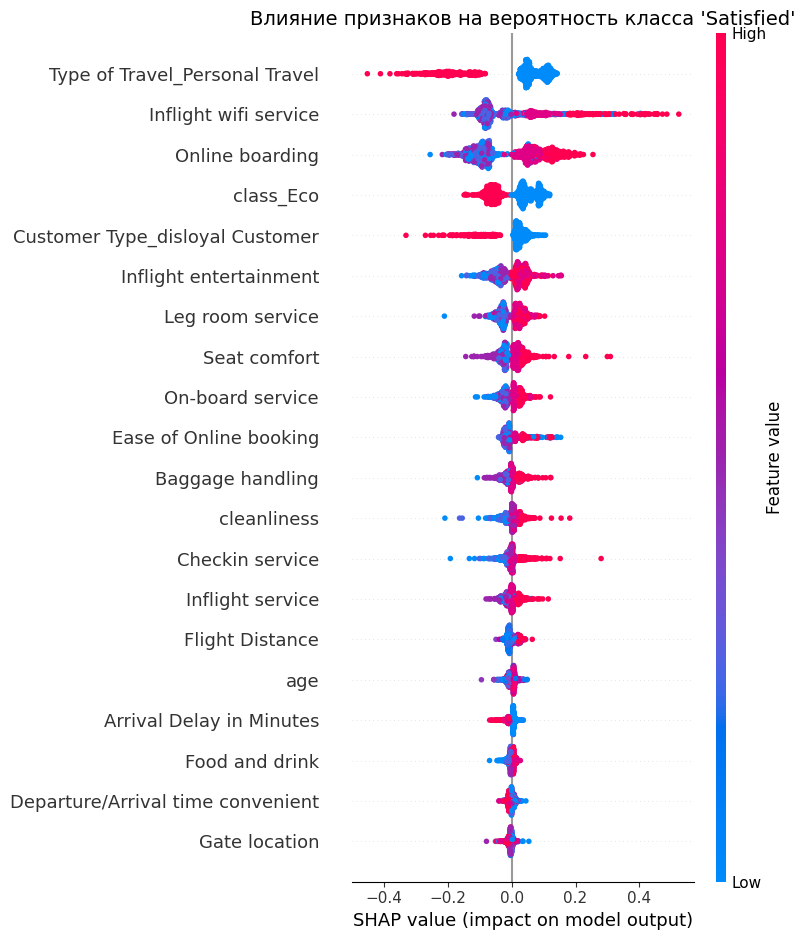

In [68]:
plt.figure(figsize=(15, 8))
plt.title("Влияние признаков на вероятность класса 'Satisfied'", fontsize=14)

shap.summary_plot(shap_values_target, X_train_sample, plot_type="dot")

График SHAP Summary Plot ранжирует признаки по их глобальной важности (вертикальная ось) и показывает распределение влияния каждого конкретного наблюдения на итоговое предсказание (горизонтальная ось).

**1. Ключевые факторы неудовлетворенности (Отрицательное влияние):**
Самые сильные факторы, которые тянут предсказание в сторону класса **0**, — это контекст поездки и статус пассажира:
*   **Type of Travel_Personal Travel**: Обладает очень сильной отрицательной корреляцией. Это значит, что если пассажир летит с личной целью (Personal), вероятность того, что он останется доволен, резко падает. И наоборот: бизнес-путешественники гораздо более склонны ставить высокие оценки.
*   **class_Eco** (Важность №4): Перелет в эконом-классе также является ярким маркером неудовлетворенности.
*   **Customer Type_disloyal Customer**: Нелояльные клиенты изначально настроены более скептически.

**2. Ключевые факторы удовлетворенности (Положительное влияние):**
Среди сервисных характеристик, которые повышают вероятность класса **1 (Satisfied)**, сильнее всего выделяются технические аспекты обслуживания:
*   **Inflight wifi service** (Важность №2): Высокая положительная корреляци. Наличие хорошего Wi-Fi — критический фактор для пассажира.
*   **Online boarding** (Важность №3): Очень сильная зависимость. Удобная онлайн-регистрация практически всегда гарантирует повышение лояльности. Если этот процесс прошел гладко (оценка 4-5), клиент с большой вероятностью будет доволен.

**3. Второстепенные, но важные факторы:**
Остальные признаки (Развлечения, Комфорт сидений, Еда, Чистота) имеют стабильную положительную корреляцию. Это означает, что чем выше оценка за сервис, тем выше итоговая удовлетворенность.

**Итоговый портрет:**
Модель считает, что **идеальный довольный клиент** — это лояльный пассажир, летящий в командировку, который легко зарегистрировался онлайн и получил качественный Wi-Fi на борту.
Напротив, пассажир, летящий по личным делам в эконом-классе скорее всего будет почти всегда недоволен, даже если его неплохо покормили (так как важность `Food and Drink` ниже, чем важность `Wifi` и `Travel Type`).

### **Бонус (0.1 балл)**

- Изучите документацию библиотеки SHAP. Что ещё полезного в ней имеется?

*   `shap.dependence_plot`: Показывает зависимость SHAP-value от значения конкретного признака, автоматически выявляя взаимодействия с другими признаками.
*   `shap.force_plot`: Интерактивная визуализация для объяснения **одного конкретного предсказания** (показывает, какие именно факторы и каким образом повлияли на предсказание).
*   `shap.decision_plot`: Визуализирует путь принятия решения для набора примеров.

### **Бонус (0.5 балла)**

- Интерпретируйте важности признаков для одного прогноза с помощью LIME;
- Опишите полученный график для выбранного наблюдения

/Users/staspog/HSE/hse-ml-homework/HW_4/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


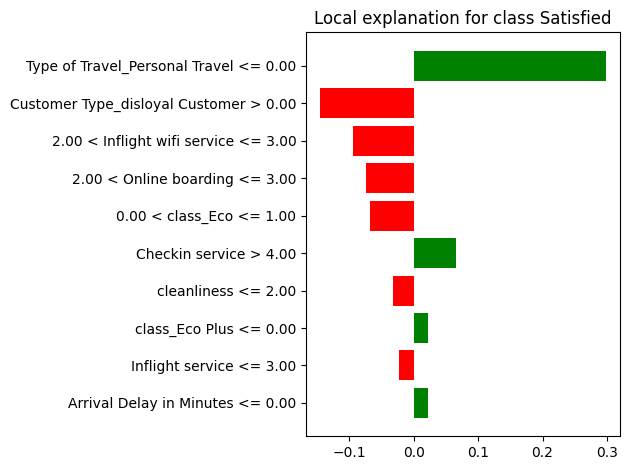

True Class: 0


In [ ]:
from IPython.display import display, HTML

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_enc),
    feature_names=X_train_enc.columns.tolist(),
    class_names=['Neutral/Dissatisfied', 'Satisfied'],
    mode='classification'
)

# Выбор наблюдения
idx = 42
instance_to_explain = X_val_enc.iloc[idx].values 

# Генерация объяснения
exp = explainer_lime.explain_instance(
    data_row=instance_to_explain,
    predict_fn=best_rf.predict_proba
)

# Почему-то встроенным методом .show_in_notebook не получилось отобразить, конфликт версий LIME и numpy, IPython и Jupyter
#  Поэтому я попросил гемини полностью вручную отобразить вывод ячейки с нужными цветами текста и фона
raw_html = exp.as_html(show_table=True)

# Оборачиваем его в div с белым фоном и черным текстом
styled_html = f"""
<div style="background-color: white; color: black; padding: 10px; border-radius: 5px;">
    {raw_html}
</div>
"""

# Отображаем
display(HTML(styled_html))

# Чтобы график matplotlib тоже был читаемым на темном фоне, 
# можно принудительно задать стиль 'default' (белый фон) перед отрисовкой
with plt.style.context('default'):
    fig = exp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

print(f"True Class: {y_val_enc.iloc[idx]}")

График показывает вклад каждого признака в вероятность того или иного класса **для данного конкретного пассажира**.
*   Зеленые полосы: Признаки, увеличивающие вероятность класса "Satisfied".
*   Красные полосы: Признаки, увеличивающие вероятность класса "Neutral/Dissatisfied".
*   Например, если `Online boarding` > 3.5, это может быть мощным фактором "За" удовлетворенность (зеленая полоса). А если `Type of Travel` = Personal, это может тянуть предсказание в классу 0.

# Обратная связь

Расскажите, как вам это домашнее задание. Было ли оно полезным? Научились ли вы чему то? Насколько сложным по 10-балльной шкале оно вам показалось? Сколько времени у вас ушло на его выполнение? Что следовало ещё в него включить? Было ли что-то лишнее?

---

Задание было однозначно полезным. Научился 100% большому числу полезных вещей. От получения данных, до LIME-анализа, про который даже не слышал раньше. По сложности 9/10. Больше всего трудностей было с типами данных. Одна библиотека хочет series, вторая массив, третья numpy-массив. 

По дороге два раза упал гугл-колаб. Один раз ровно между часовым обучением кучи RF-моделей и сохранением лучшей из них в файл. После этого я решил переехать в локальный ноутбук. Тут уже были сложности с окружениями и версиями библиотек. 

Наиболее полезным для себя могу выделить ряд заданий про калибровку вероятностей. Казалось бы, очевидный факт, что просить неоткалиброванное дерево предсказать вероятности - плохая идея, просто ввиду природы самого дерева и того, как оно строится. Но раньше никогда об этом не задумывался.

На выполнение ушло 8 часов. Вечер + утро.


Что можно было бы ещё включить - подбор гиперпараметров при помощи optuna или hyperopt. И минимальный разбор этих методов. Обрадовался, что они будут наконец-то, когда увидел их в импортах, но в итоге подбирали при помощи RSCV.